# Topographic-control transition case studies

This notebook automatically identifies long-lived eddies that spend sustained periods in both planetary- and topographic-PV-gradient regimes. These tracks provide an internal reference: changes in tilt can be compared within the same eddy as it approaches, crosses, or leaves strong bathymetric gradients.

The diagnostic is $R = \log(|\nabla q|_{topographic}/|\nabla q|_{planetary})$, where $R<0$ is planetary-dominant and $R>0$ is topographic-dominant. Ranking is performed separately for anticyclonic (AE) and cyclonic (CE) eddies so that the initial comparison contains equal numbers of each polarity.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd().resolve()
ANALYSIS_ROOT = next(
    (p for p in (HERE, *HERE.parents) if (p / 'seacofs_tilt_tools.py').exists()),
    None,
)
if ANALYSIS_ROOT is None:
    raise FileNotFoundError('Run from seacofs_eddy_tilt_analysis or one of its subfolders.')
CASE_ROOT = ANALYSIS_ROOT / 'case_studies'
for path in (CASE_ROOT, ANALYSIS_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import seacofs_tilt_tools as tilt
from case_study_tools import (
    TransitionConfig,
    plot_topographic_transition,
    rank_topographic_transitions,
    select_top_cases,
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)

## 1. Load the vertically checked eddy dataset

Core-mean bathymetry and gradients are used because the process should represent the bathymetry experienced across the eddy core, rather than a single centre grid cell. This is the expensive step. Set `CORE_MEAN_FOR_SCREENING = False` for a quick preliminary screen, then rerun selected cases with core means before interpreting them.

In [2]:
CORE_MEAN_FOR_SCREENING = True

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df_eddies, _ = tilt.load_tilt_tables(paths)
df_eddies = tilt.add_region_labels(df_eddies, grid)
df_eddies = tilt.add_pv_gradient_terms(
    df_eddies, grid, core_mean=CORE_MEAN_FOR_SCREENING
)

required = {'Eddy', 'Day', 'Cyc', 'TiltDis', 'TiltDir', 'topo_plan_ratio'}
missing = required - set(df_eddies.columns)
if missing:
    raise KeyError(f'Missing required columns: {sorted(missing)}')
if df_eddies.duplicated(['Eddy', 'Day']).any():
    raise ValueError('Expected one row per Eddy-Day.')

print(f"{len(df_eddies):,} observations from {df_eddies.Eddy.nunique():,} eddies")
display(df_eddies.groupby('Cyc').agg(observations=('Eddy', 'size'), eddies=('Eddy', 'nunique')))

127,426 observations from 2,982 eddies


,observations,eddies
Cyc,,
AE,64952,1446
CE,62474,1536


## 2. Define an ideal transition candidate

The defaults require a lifetime of at least 100 days, at least 10 valid observations in each regime, a run of at least five consecutive smoothed observations in each regime, and at least 20 valid tilt estimates. A centred seven-observation rolling median suppresses isolated crossings.

Eligible eddies are scored using lifetime (20%), balance between regimes (25%), shorter of the two sustained runs (20%), separation of regime medians (15%), few clean crossings (10%), and tilt-data coverage (10%). All score components are percentile-ranked within AE or CE.

In [3]:
config = TransitionConfig(
    smooth_window=7,
    min_periods=5,
    min_lifetime_days=100,
    min_regime_observations=10,
    min_sustained_run=5,
    min_tilt_observations=20,
    regime_margin=0.0,
)

df_transition, ranking = rank_topographic_transitions(df_eddies, config)
eligibility = ranking.groupby('Cyc')['eligible'].agg(candidates='size', eligible='sum')
display(eligibility)

/home/z5297792/myenv310/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/z5297792/myenv310/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/z5297792/myenv310/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/z5297792/myenv310/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/z5297792/myenv310/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/z5297792/myenv310/lib/python3.10/site-packages/numpy/lib/_nanfunctions_imp

,candidates,eligible
Cyc,,
AE,1446,69
CE,1536,18


## 3. Inspect the ranked candidates

High scores indicate useful presentation cases, not proof that topography caused their tilt. Before selecting a final case, inspect the trajectory and confirm that the transition corresponds to a coherent encounter with shelf or slope bathymetry rather than a boundary artefact or a brief return crossing.

In [4]:
ranking_columns = [
    'Eddy', 'Cyc', 'Region', 'transition_score', 'lifetime_days',
    'planetary_fraction', 'topographic_fraction', 'regime_balance',
    'longest_planetary_run', 'longest_topographic_run',
    'regime_separation', 'sign_changes', 'tilt_coverage', 'median_tilt_km',
]
for cyc in ['AE', 'CE']:
    print(f'\nTop {cyc} transition candidates')
    display(ranking.loc[(ranking.Cyc == cyc) & ranking.eligible, ranking_columns].head(20).round(3))


Top AE transition candidates


,Eddy,Cyc,Region,transition_score,lifetime_days,planetary_fraction,topographic_fraction,regime_balance,longest_planetary_run,longest_topographic_run,regime_separation,sign_changes,tilt_coverage,median_tilt_km
0,42,AE,D1,0.863,118.0,0.590,0.410,0.821,69,48,2.214,1,0.950,9.001
1,2255,AE,D1,0.860,214.0,0.488,0.512,0.977,42,54,2.731,9,0.972,10.356
2,2361,AE,D1,0.857,113.0,0.500,0.500,1.000,39,33,3.081,5,0.947,20.969
3,809,AE,D1,0.852,108.0,0.617,0.383,0.766,66,41,2.292,1,0.945,14.114
4,6,AE,S2,0.852,226.0,0.524,0.476,0.951,47,53,2.255,8,0.974,5.443
5,356,AE,S2,0.851,243.0,0.388,0.612,0.777,81,137,2.948,3,0.975,19.354
6,604,AE,D1,0.844,138.0,0.723,0.277,0.555,99,38,3.924,1,0.957,17.500
7,1675,AE,D1,0.842,151.0,0.507,0.493,0.987,51,29,1.645,6,0.961,12.534
8,184,AE,D1,0.838,436.0,0.474,0.526,0.947,45,45,1.477,24,0.986,6.895
9,413,AE,D1,0.837,104.0,0.417,0.583,0.835,28,45,3.434,4,0.943,9.930



Top CE transition candidates


,Eddy,Cyc,Region,transition_score,lifetime_days,planetary_fraction,topographic_fraction,regime_balance,longest_planetary_run,longest_topographic_run,regime_separation,sign_changes,tilt_coverage,median_tilt_km
1446,20,CE,D2,0.832,178.0,0.299,0.701,0.599,36,116,1.898,3,0.966,9.262
1447,1044,CE,D1,0.831,113.0,0.321,0.679,0.643,18,41,3.111,4,0.947,9.669
1448,933,CE,D1,0.831,123.0,0.377,0.623,0.754,33,44,1.383,5,0.952,8.539
1449,1105,CE,D1,0.825,116.0,0.313,0.687,0.626,28,32,1.659,4,0.949,5.616
1450,1042,CE,D1,0.818,108.0,0.439,0.561,0.879,29,25,0.660,6,0.945,6.967
1451,397,CE,D1,0.817,182.0,0.243,0.757,0.486,19,101,1.766,6,0.967,9.331
1452,2786,CE,D2,0.814,140.0,0.245,0.755,0.489,21,83,1.446,5,0.957,17.696
1453,375,CE,D1,0.814,124.0,0.350,0.650,0.699,30,40,1.242,4,0.896,17.972
1454,751,CE,D1,0.813,188.0,0.294,0.706,0.588,22,73,1.045,10,0.968,7.066
1455,2162,CE,D1,0.810,176.0,0.251,0.749,0.503,24,69,1.068,7,0.966,8.404


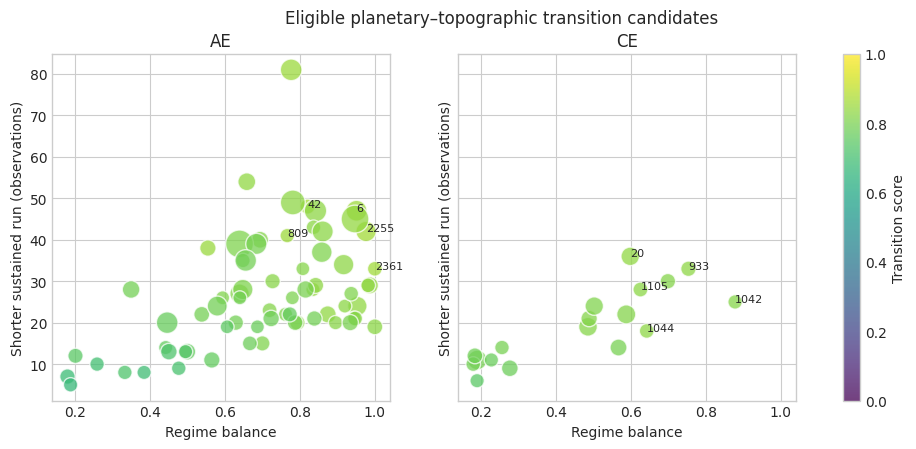

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True, sharey=True)
eligible = ranking[ranking.eligible].copy()
for ax, cyc in zip(axes, ['AE', 'CE']):
    part = eligible[eligible.Cyc == cyc]
    sc = ax.scatter(part.regime_balance, part.sustained_run_min, c=part.transition_score,
                    s=np.clip(part.lifetime_days, 50, 400), cmap='viridis',
                    vmin=0, vmax=1, alpha=0.75, edgecolor='white')
    for row in part.nlargest(5, 'transition_score').itertuples():
        ax.annotate(str(row.Eddy), (row.regime_balance, row.sustained_run_min), fontsize=8)
    ax.set(title=cyc, xlabel='Regime balance', ylabel='Shorter sustained run (observations)')
fig.colorbar(sc, ax=axes, label='Transition score')
fig.suptitle('Eligible planetary–topographic transition candidates');

## 4. Select equal numbers of AE and CE cases

The default selection uses the three highest-ranked eligible eddies of each polarity. Edit `selected` after examining the candidate figures if a track is affected by coastline geometry, missing data, or an unhelpful repeated crossing.

In [6]:
N_PER_POLARITY = 10
selected = select_top_cases(ranking, n_per_polarity=N_PER_POLARITY)
selected

{'AE': [42, 2255, 2361, 809, 6, 356, 604, 1675, 184, 413],
 'CE': [20, 1044, 933, 1105, 1042, 397, 2786, 375, 751, 2162]}

## 5. Plot the selected cases

Vertical dotted lines mark crossings of the smoothed dominance ratio. The map is coloured by the same ratio: blue is planetary dominance and red is topographic dominance. Direction panels use compass bearings, with 0/360° north, 90° east, 180° south and 270° west.

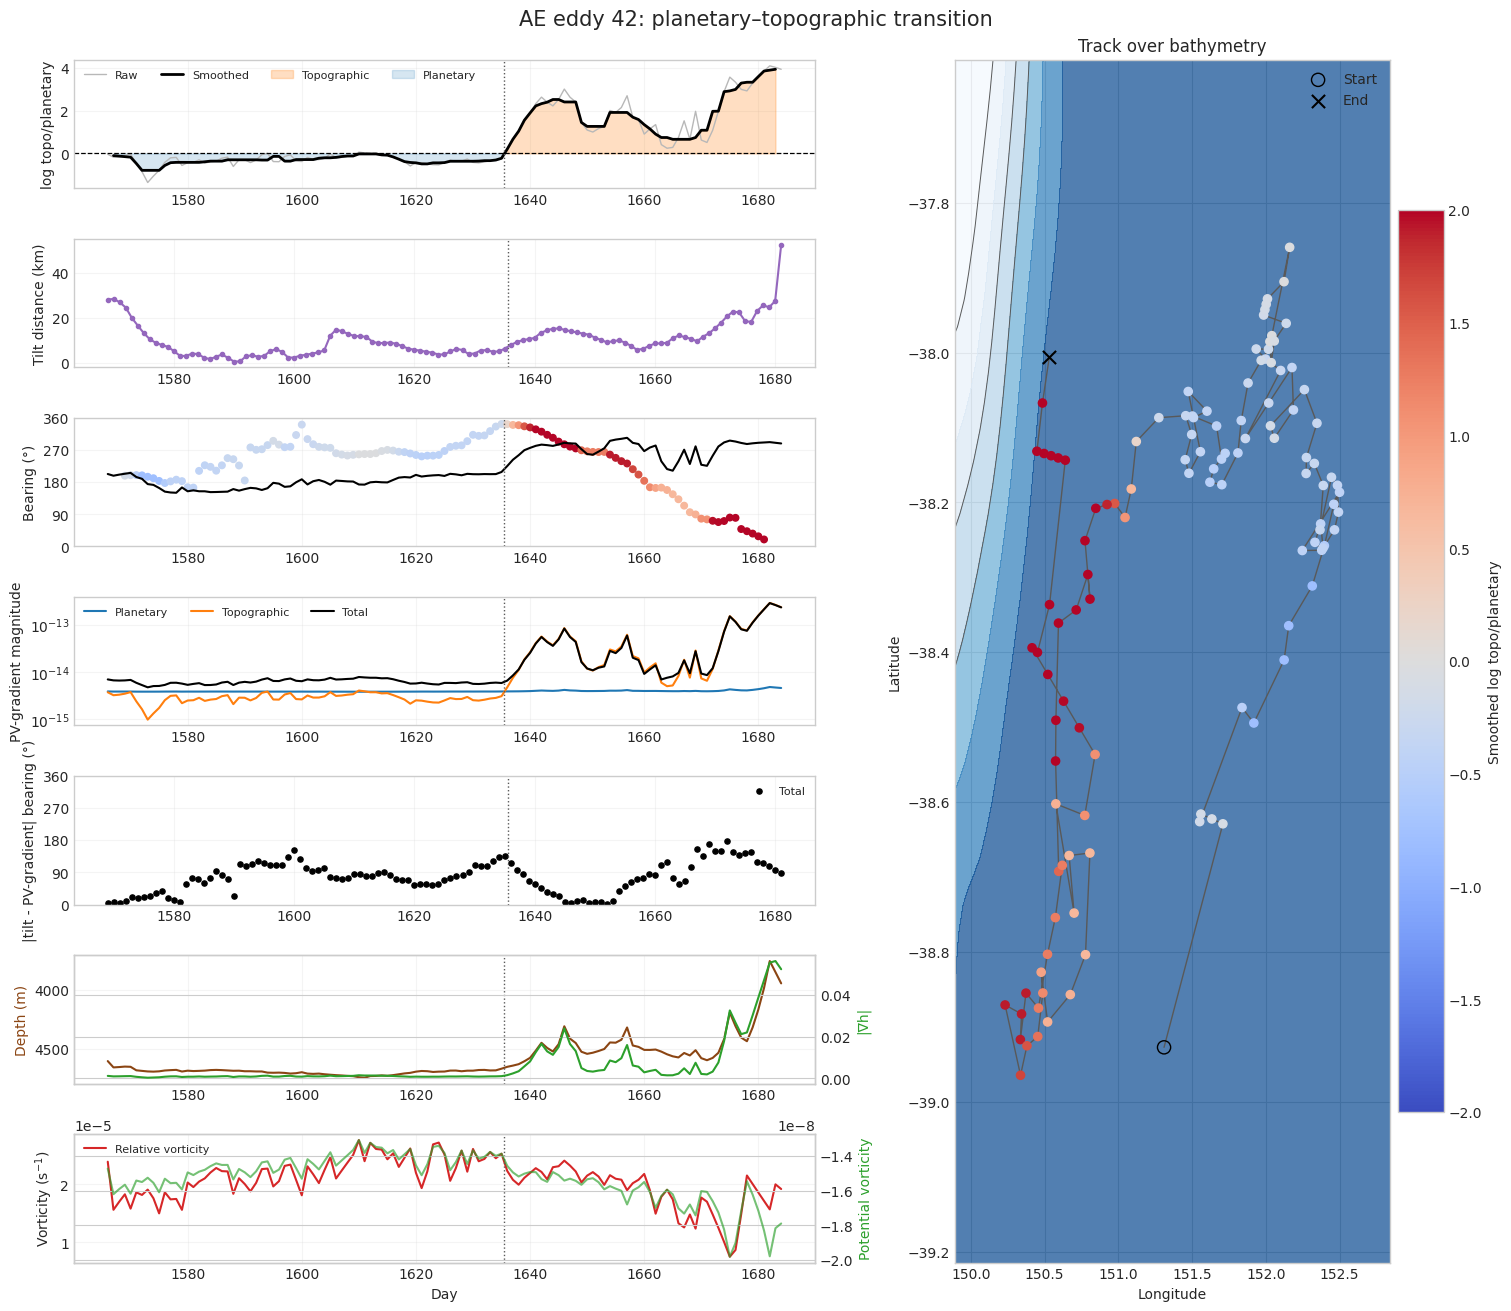

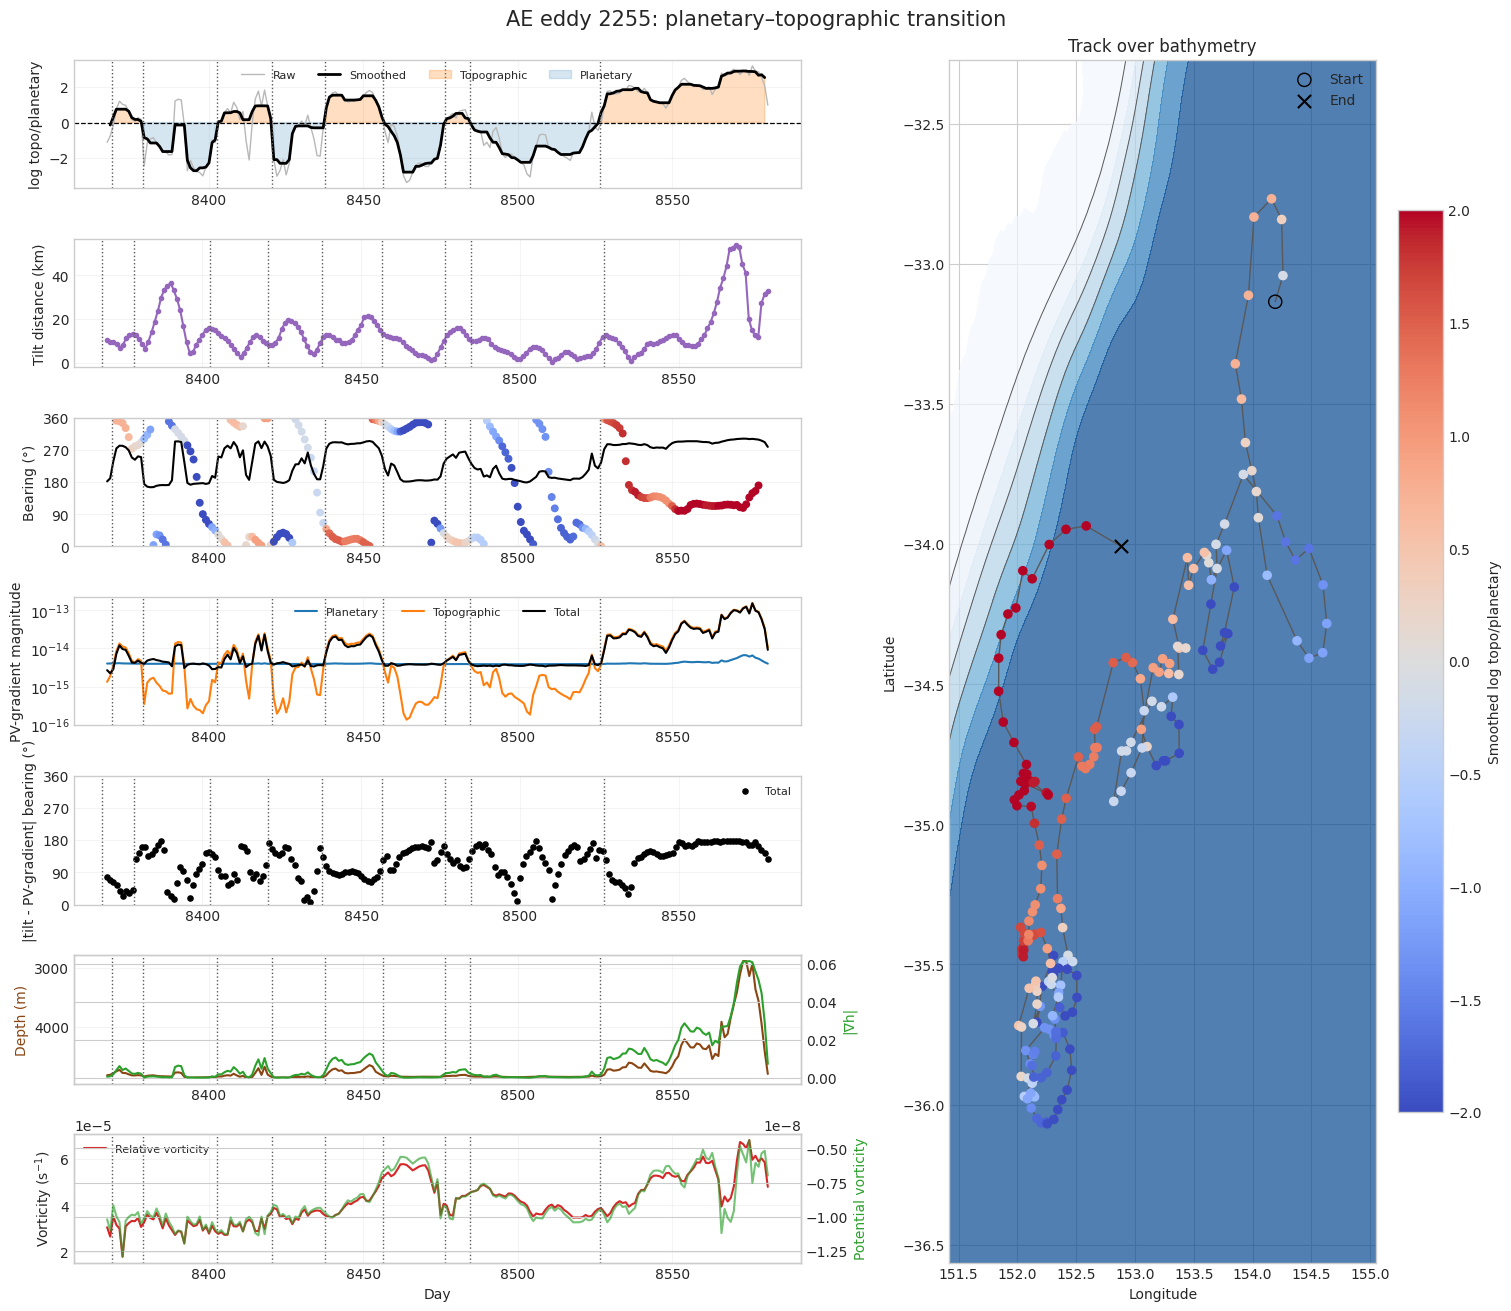

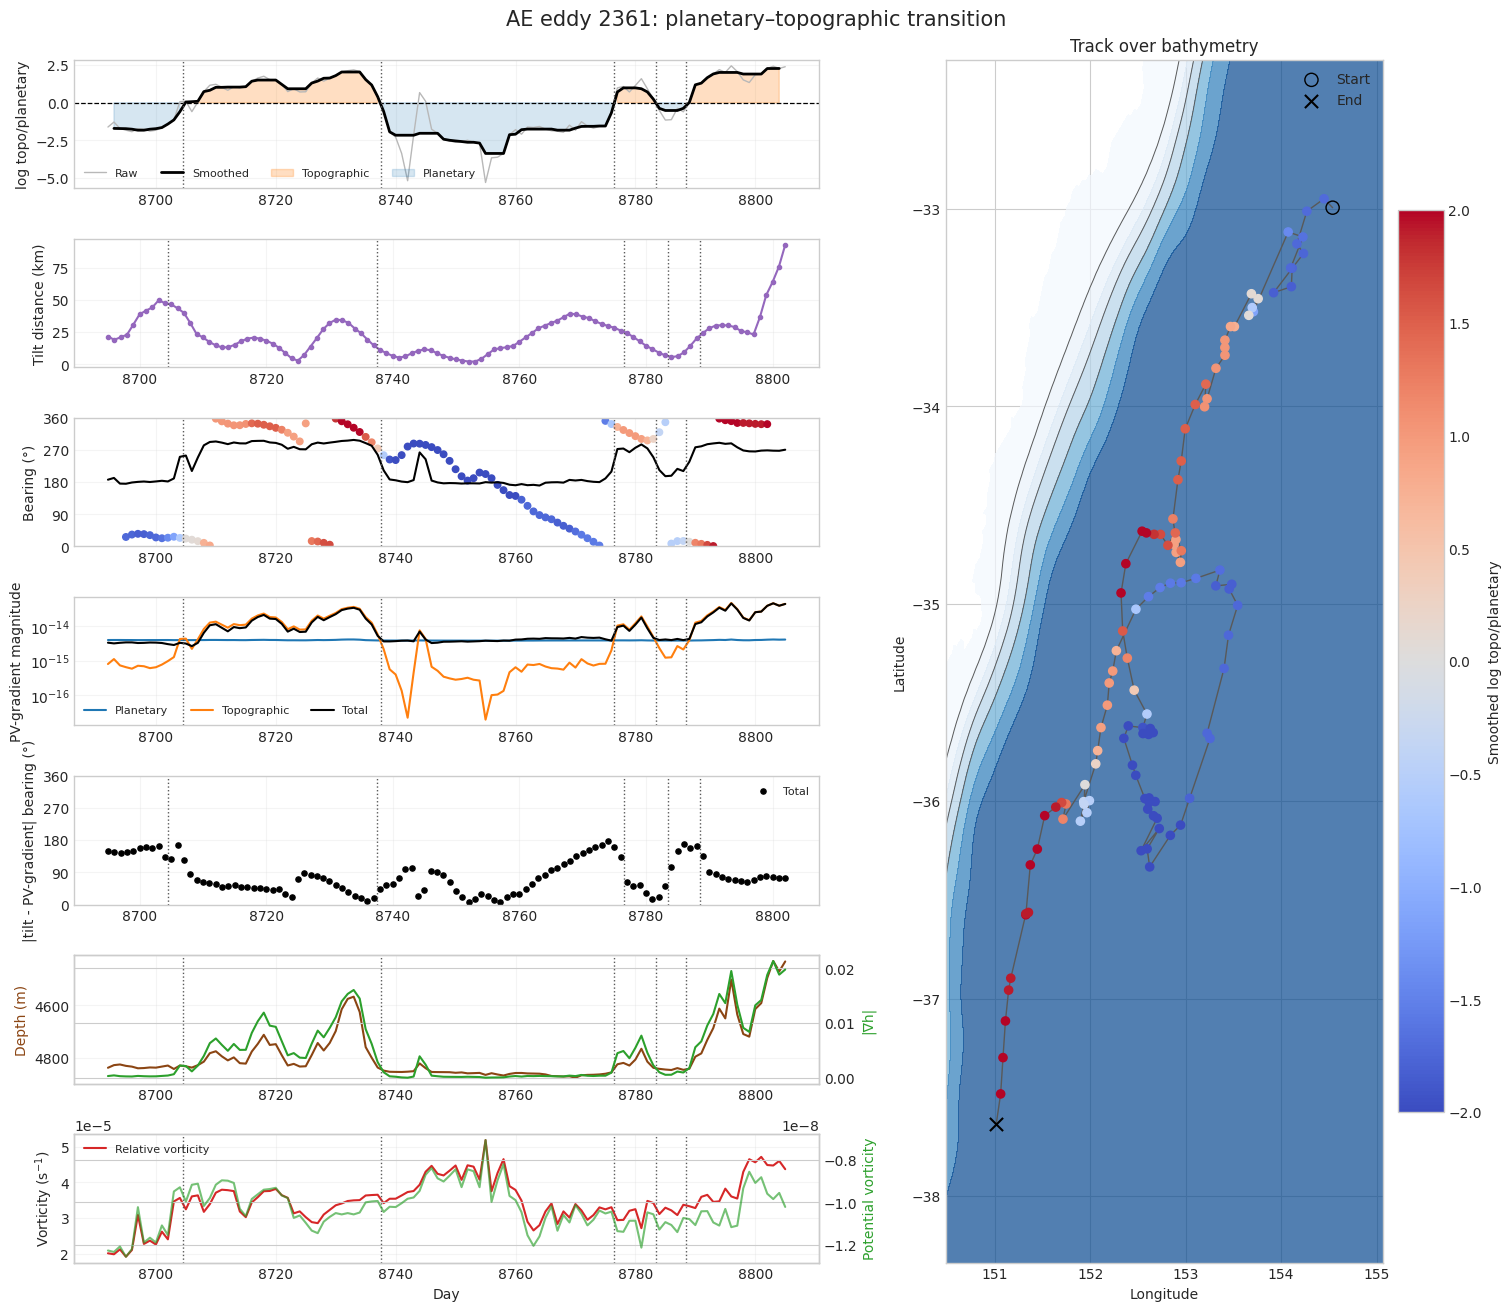

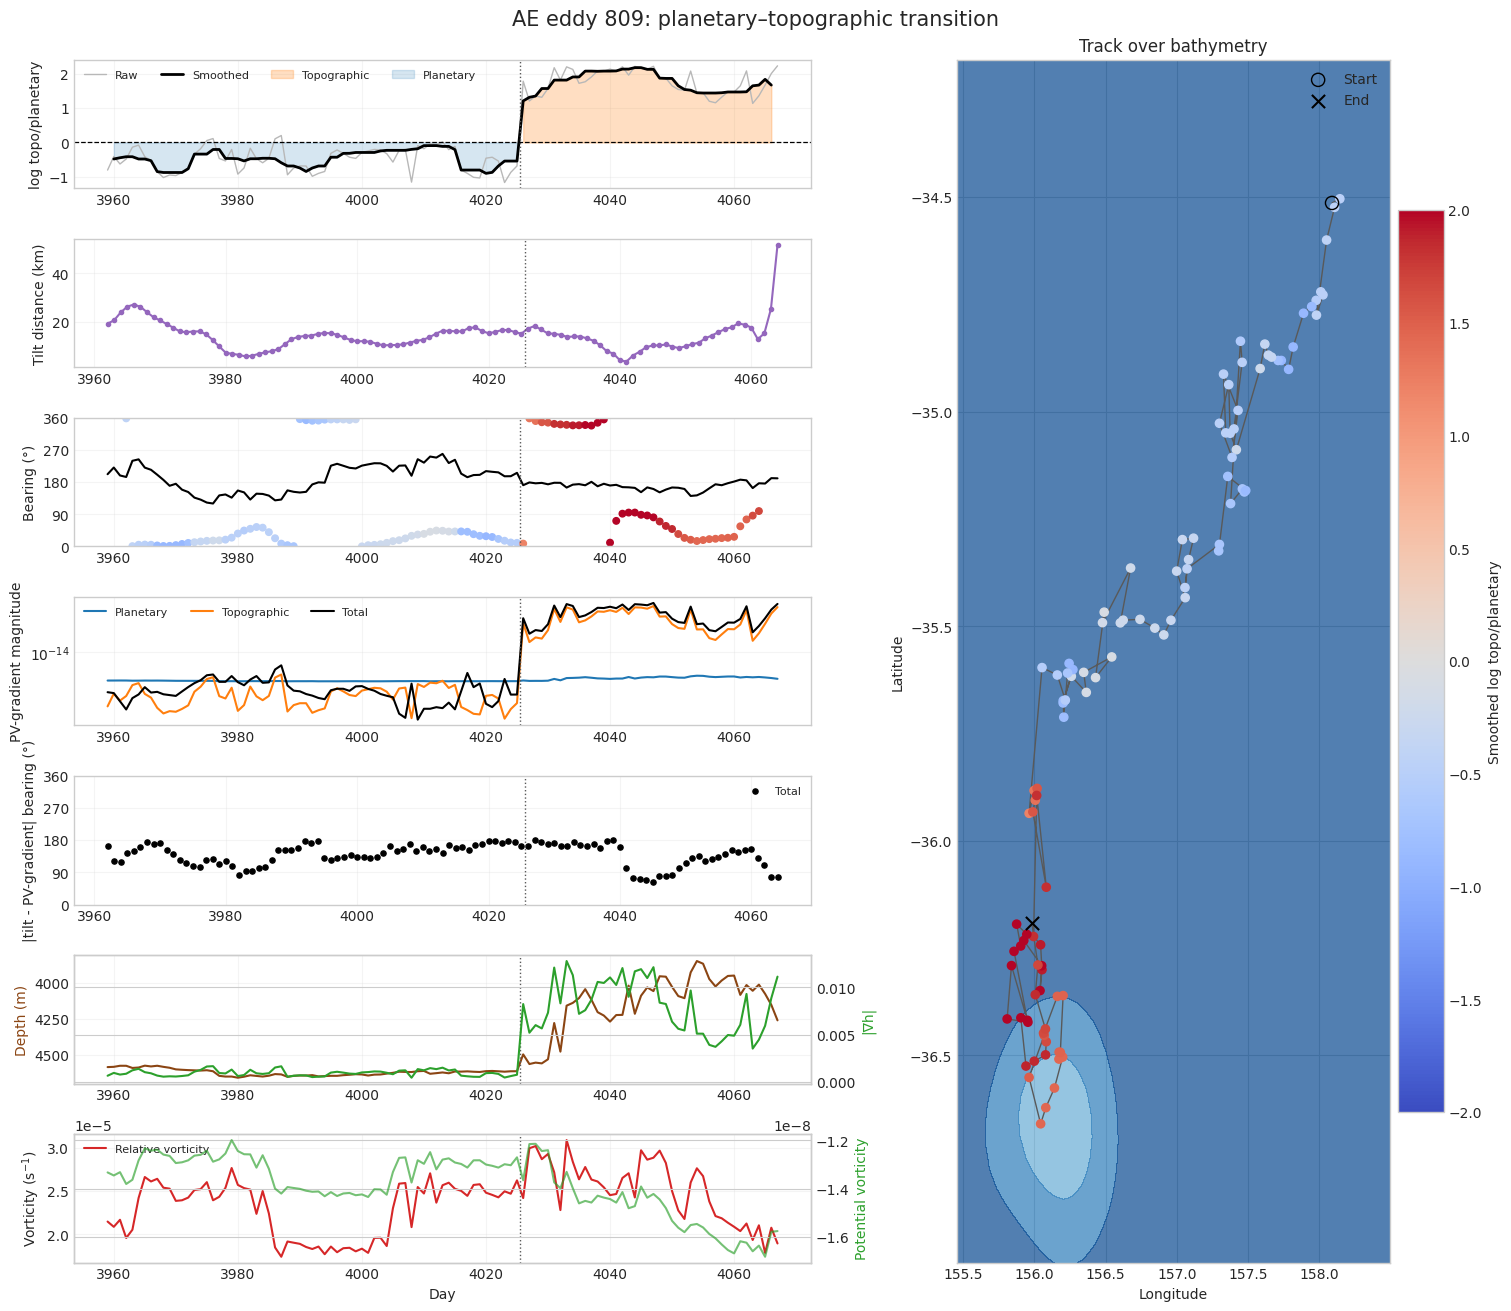

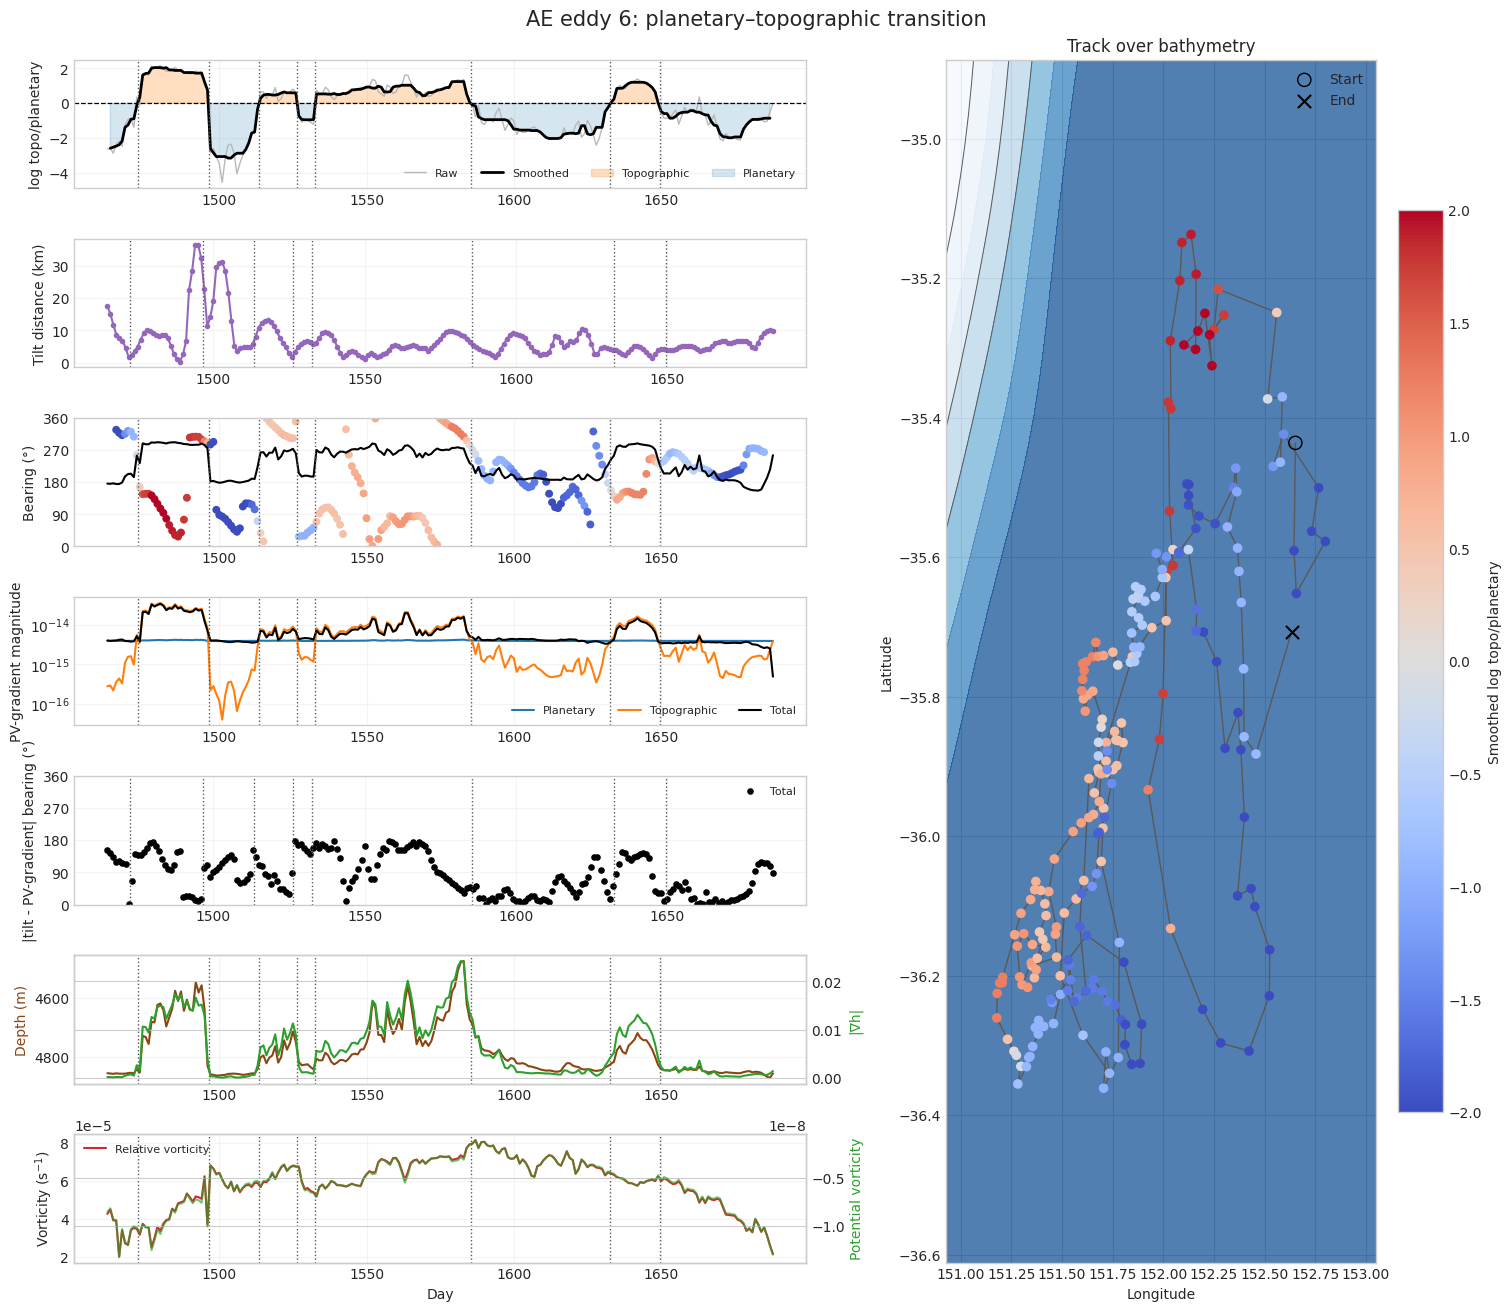

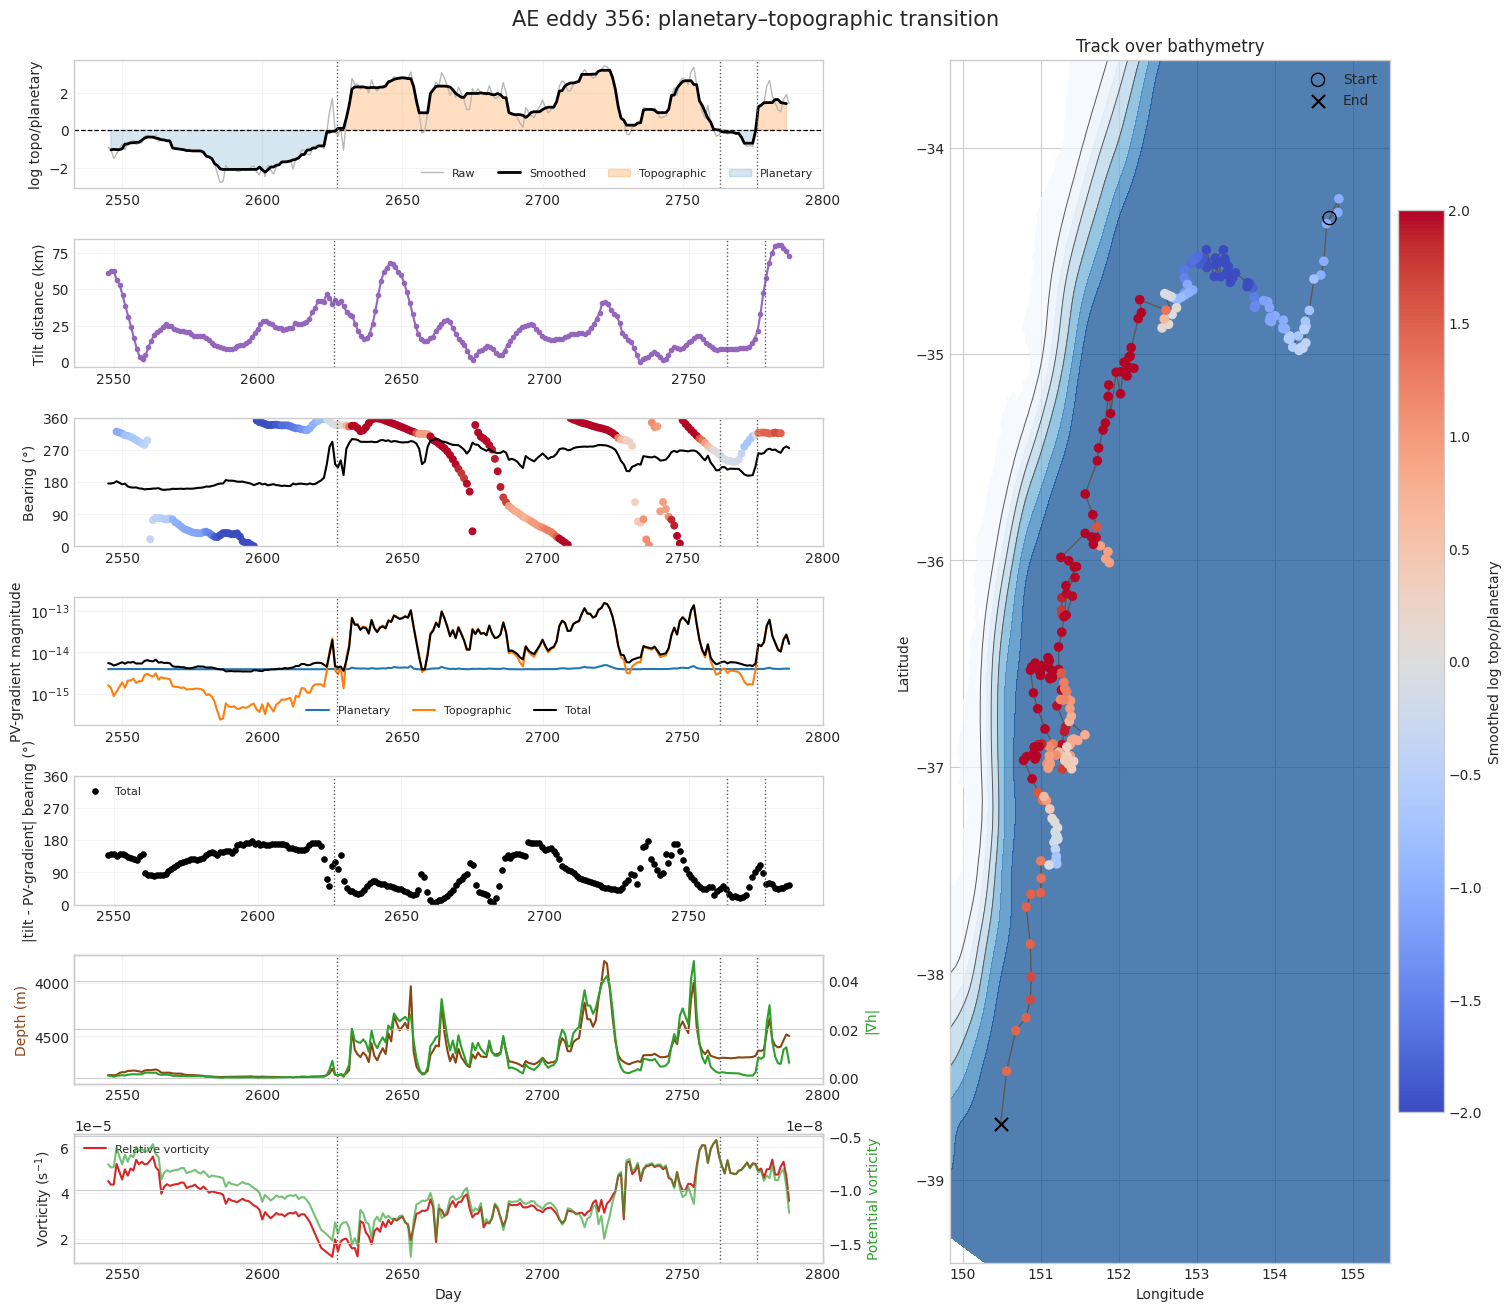

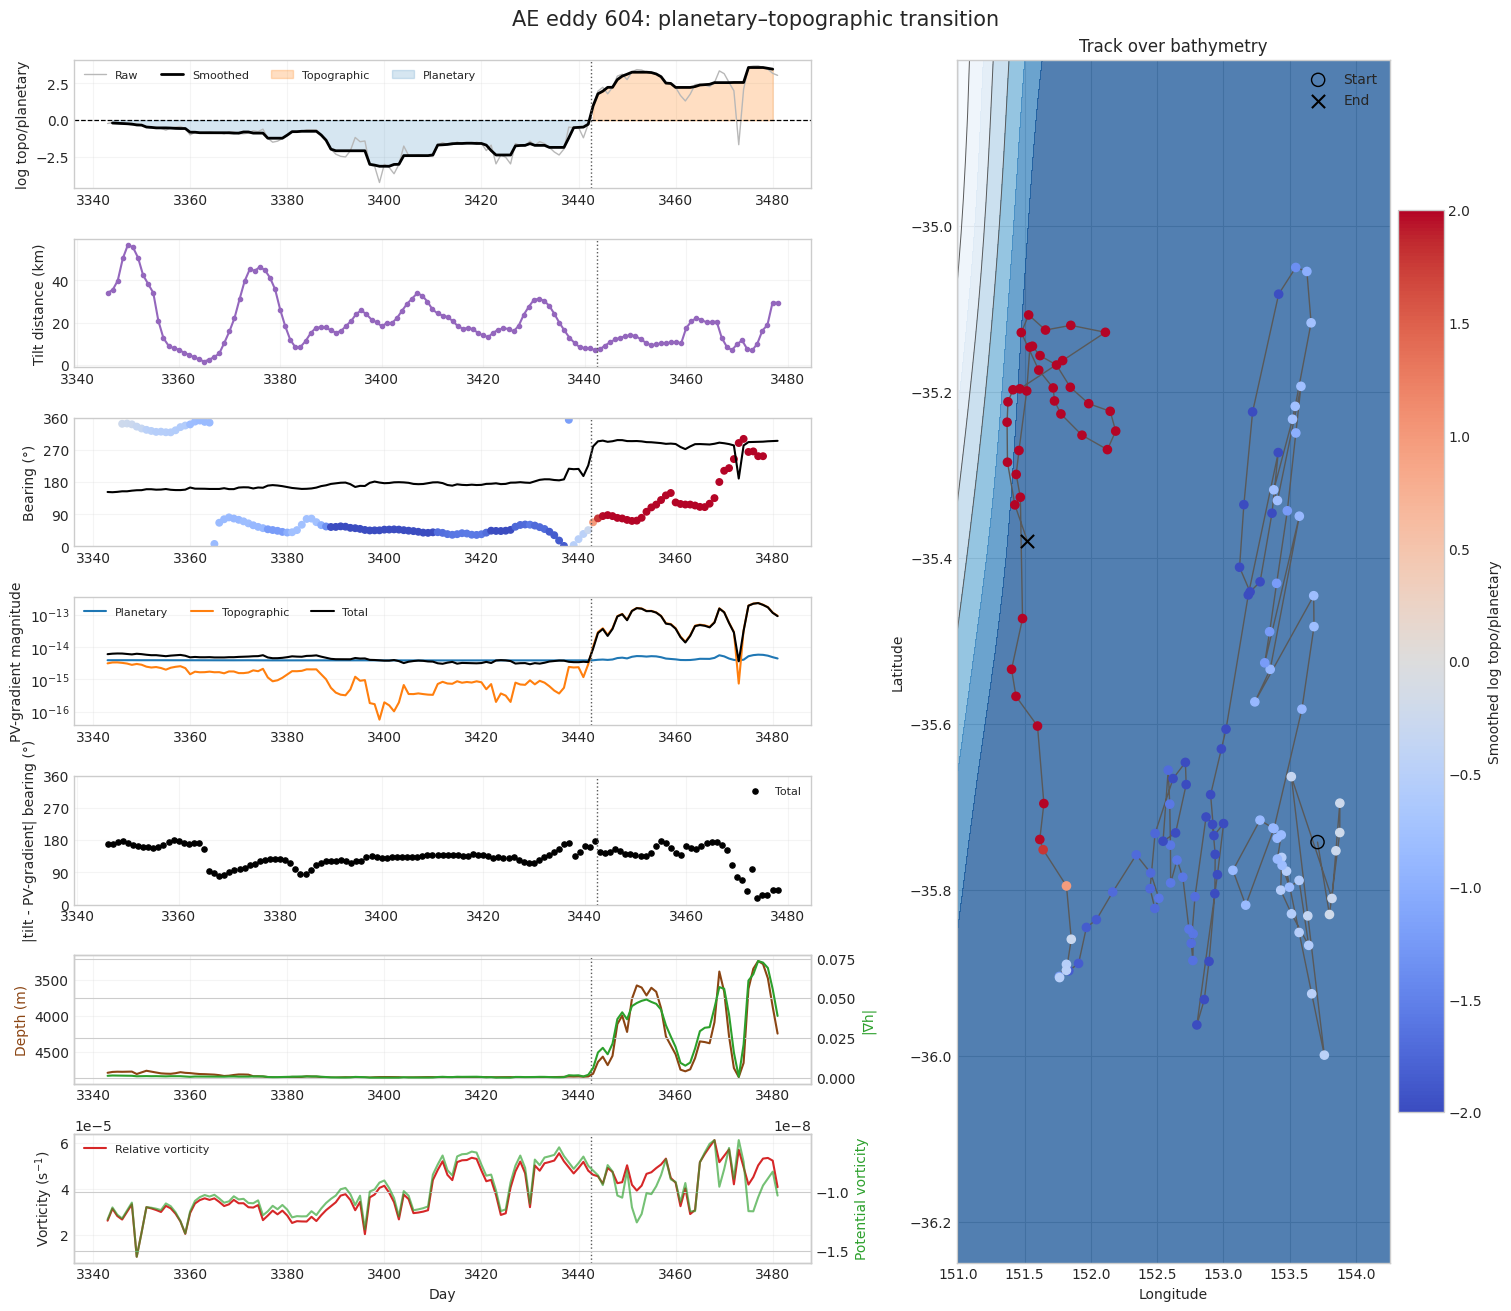

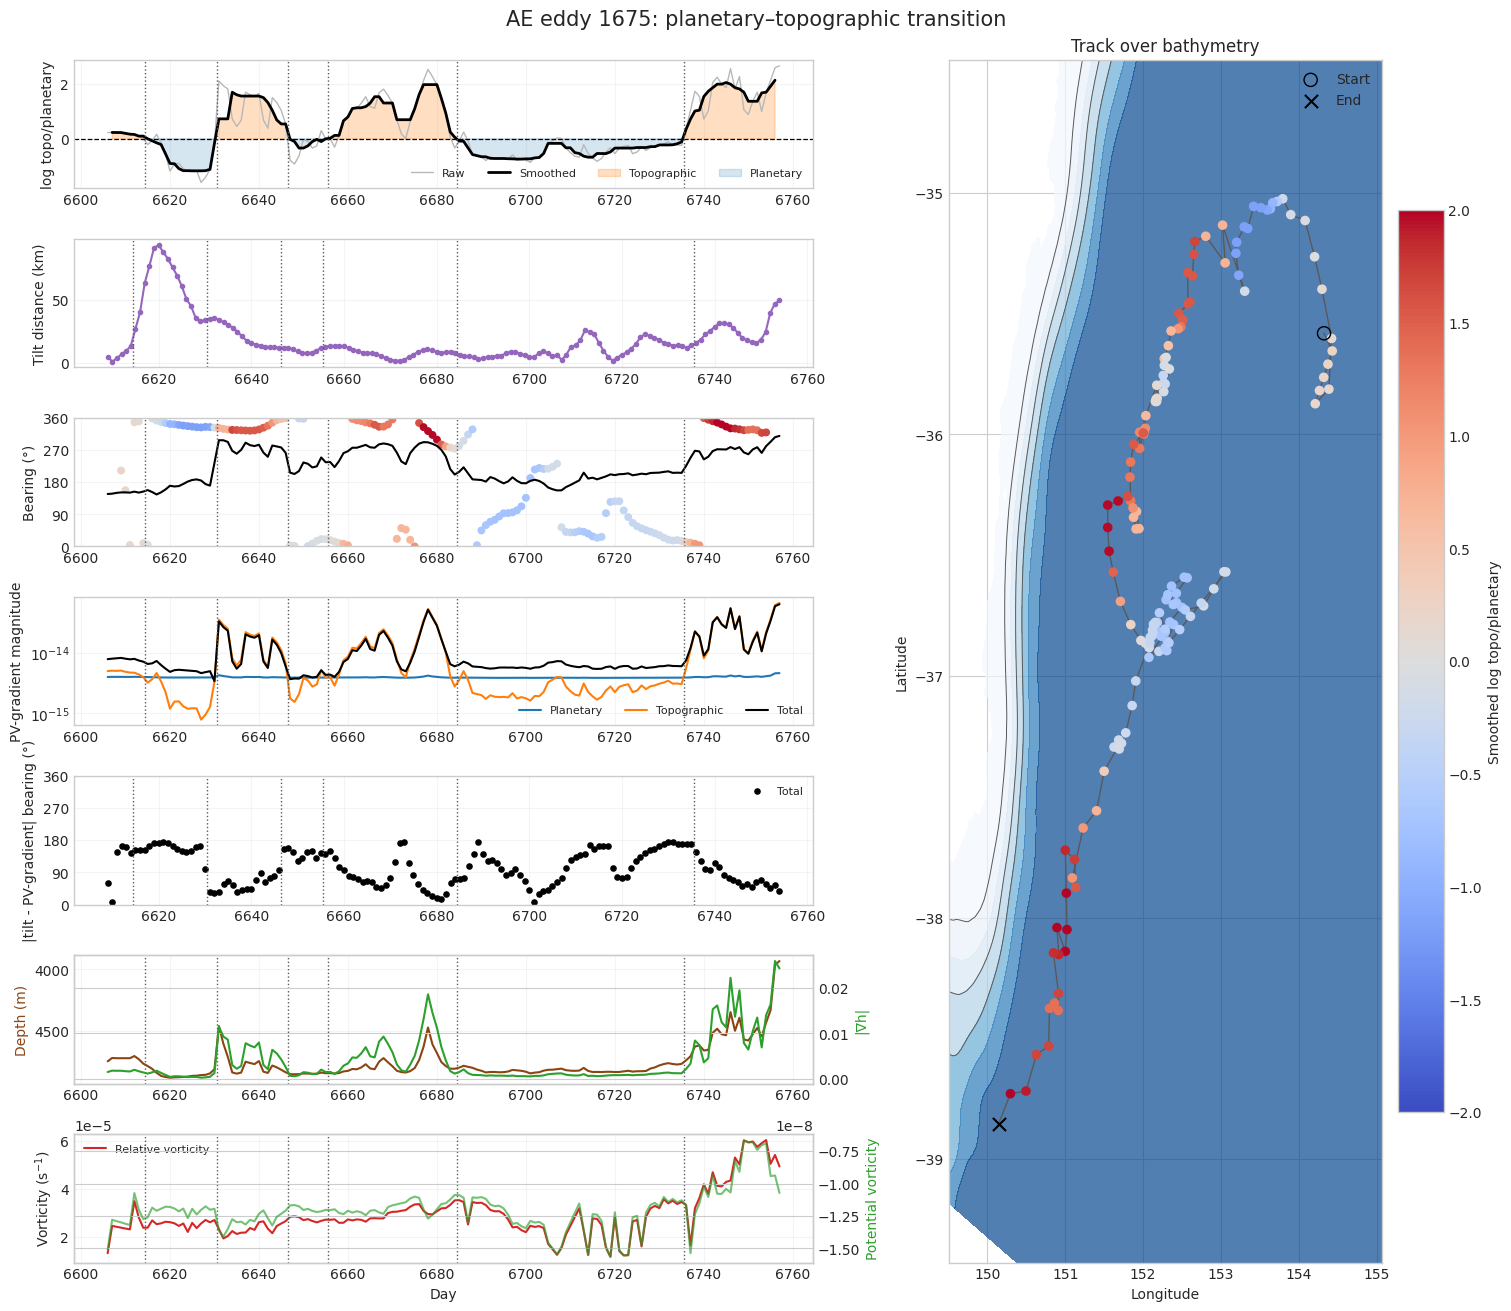

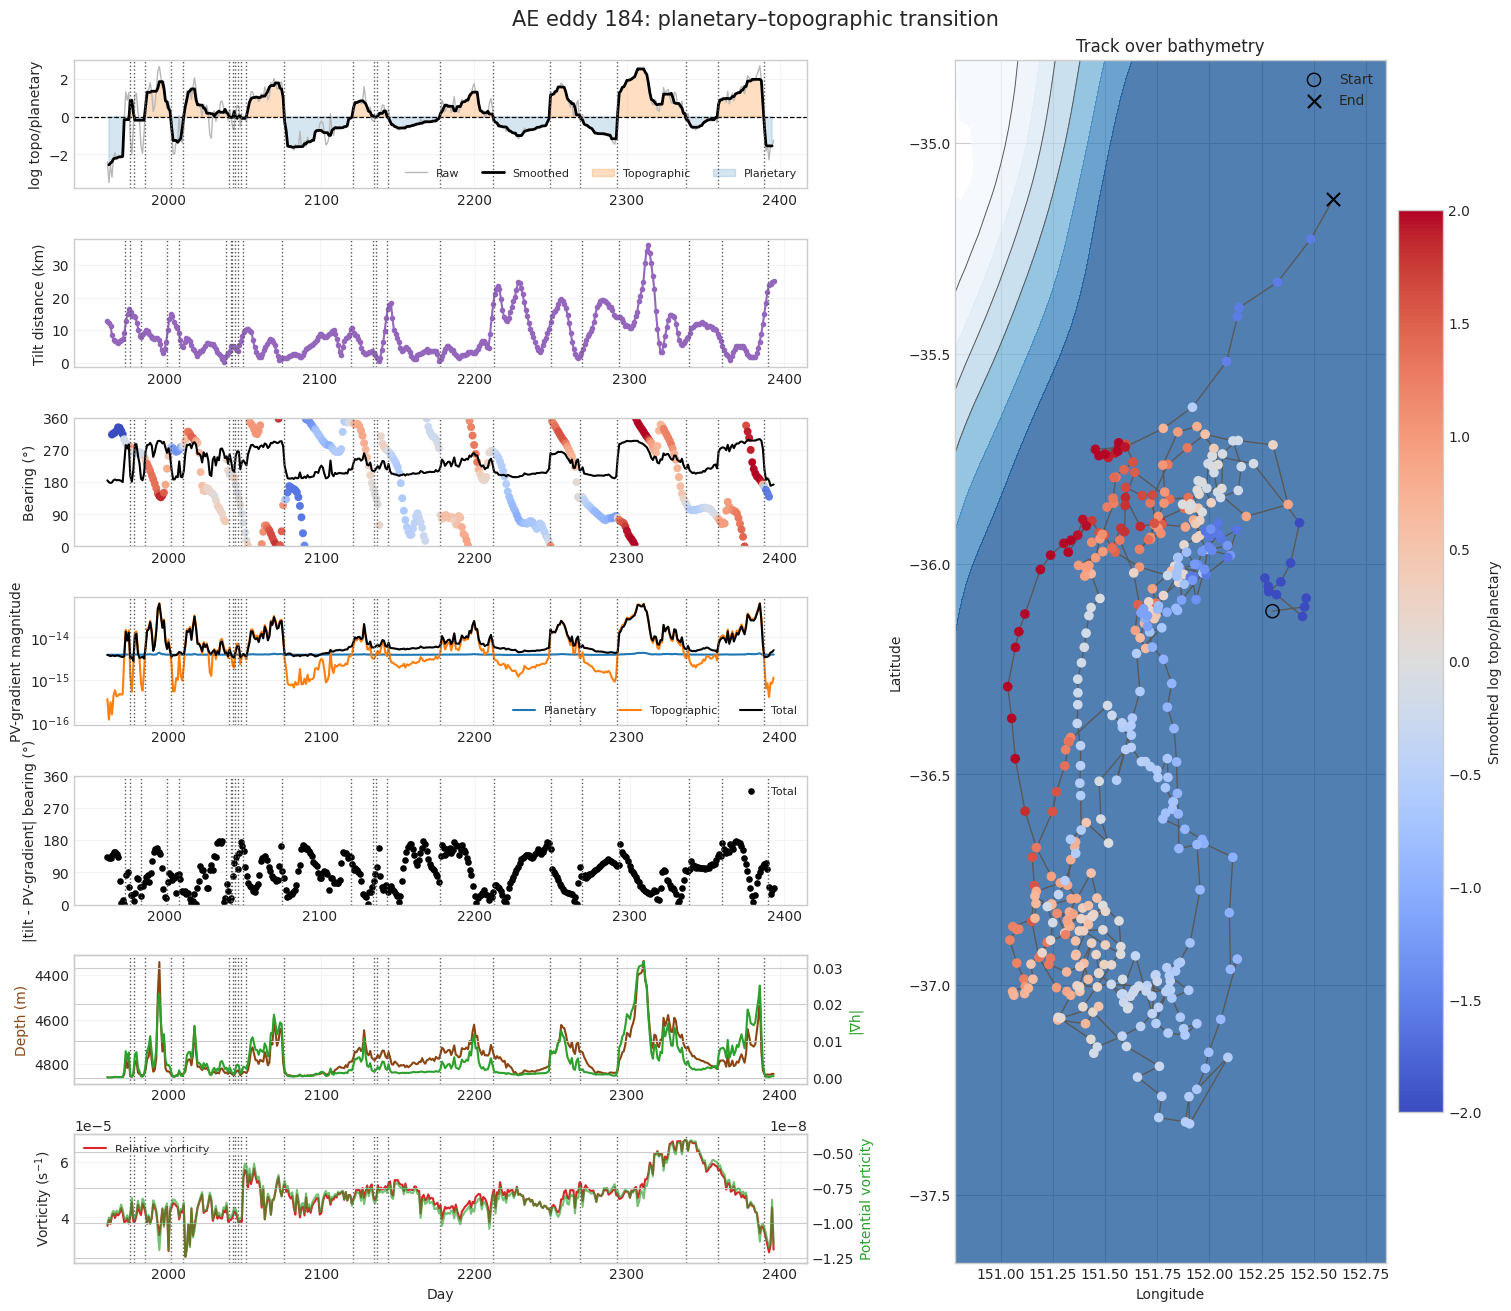

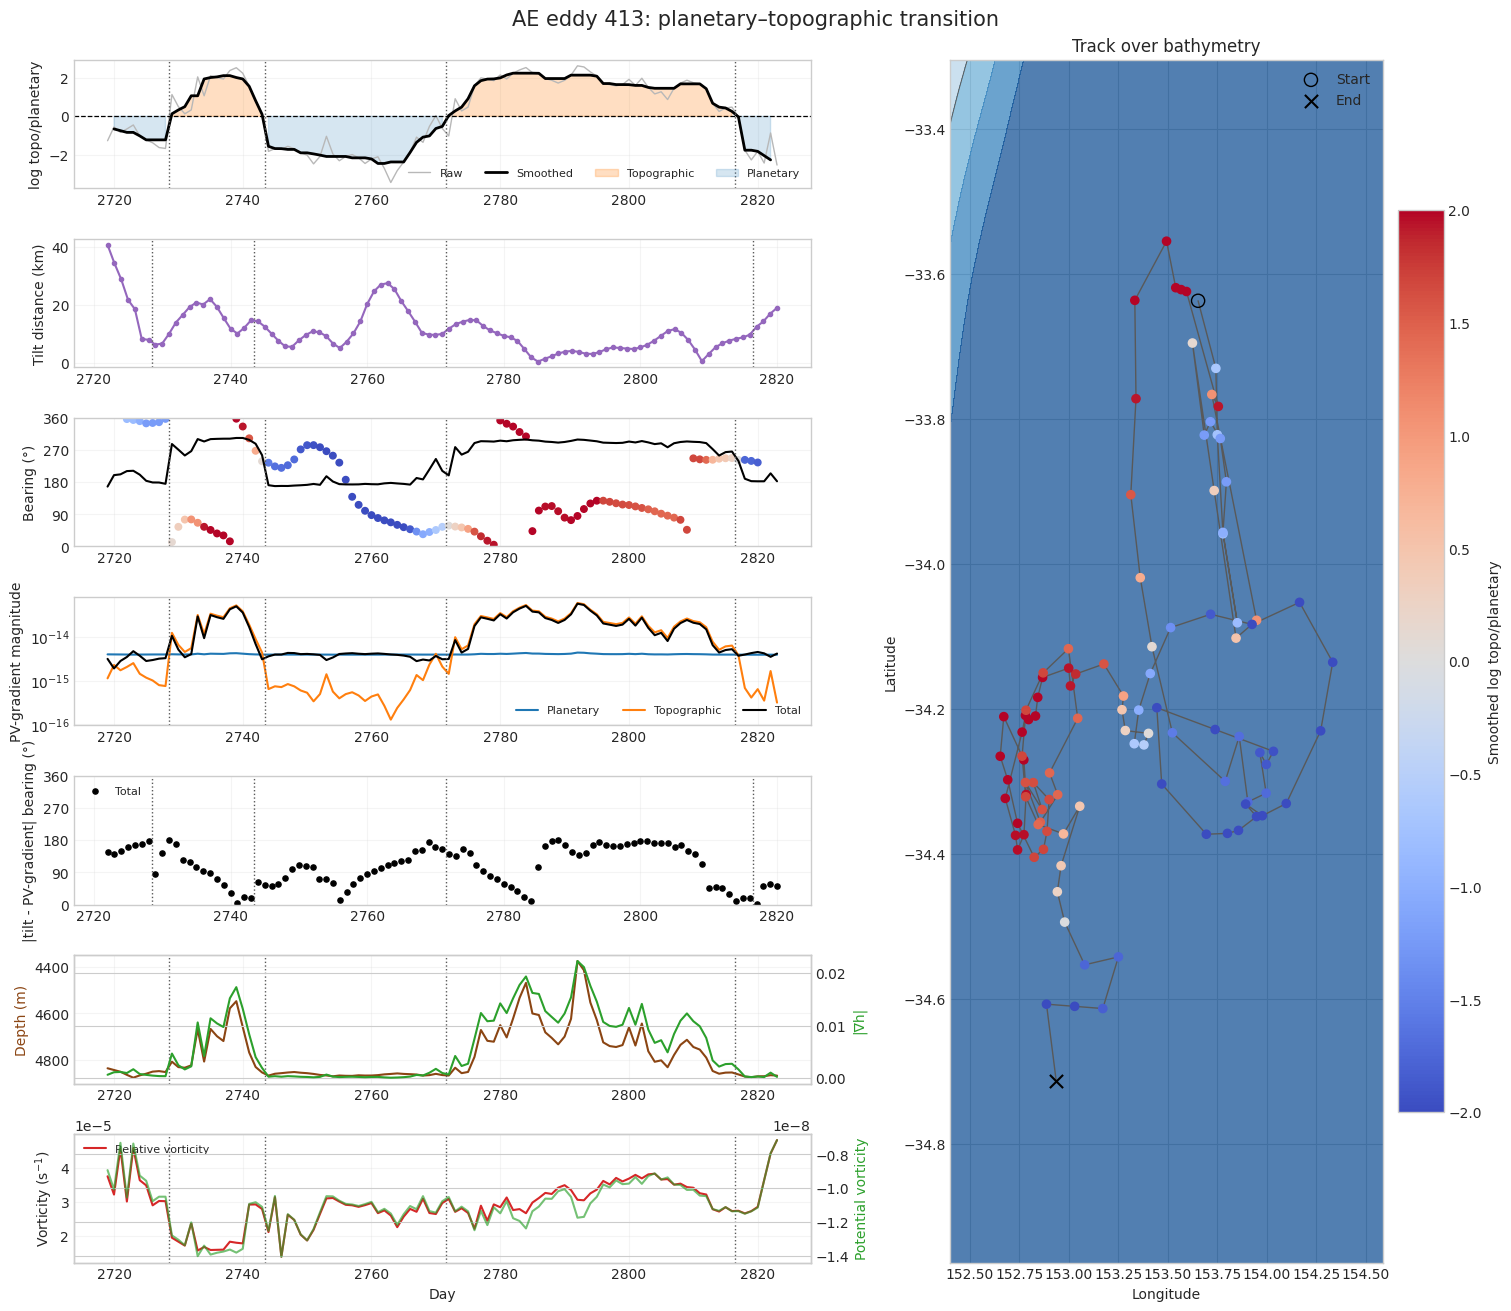

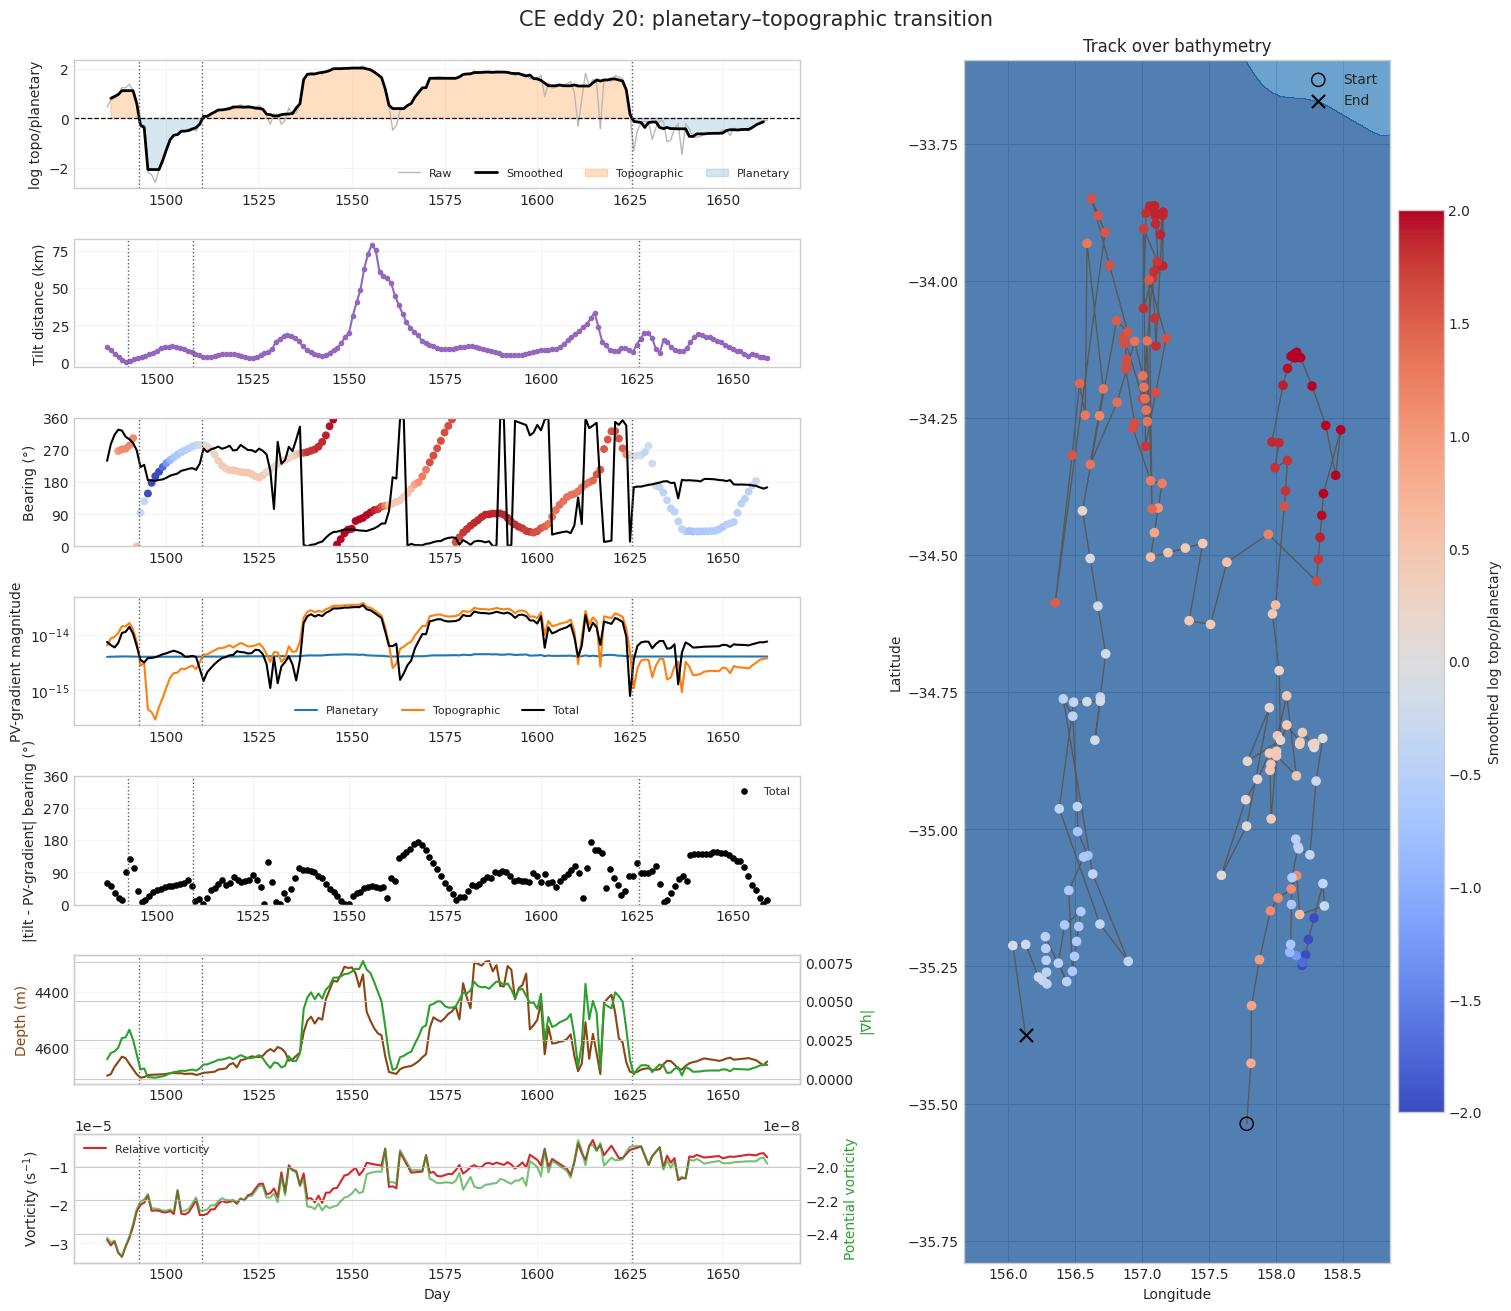

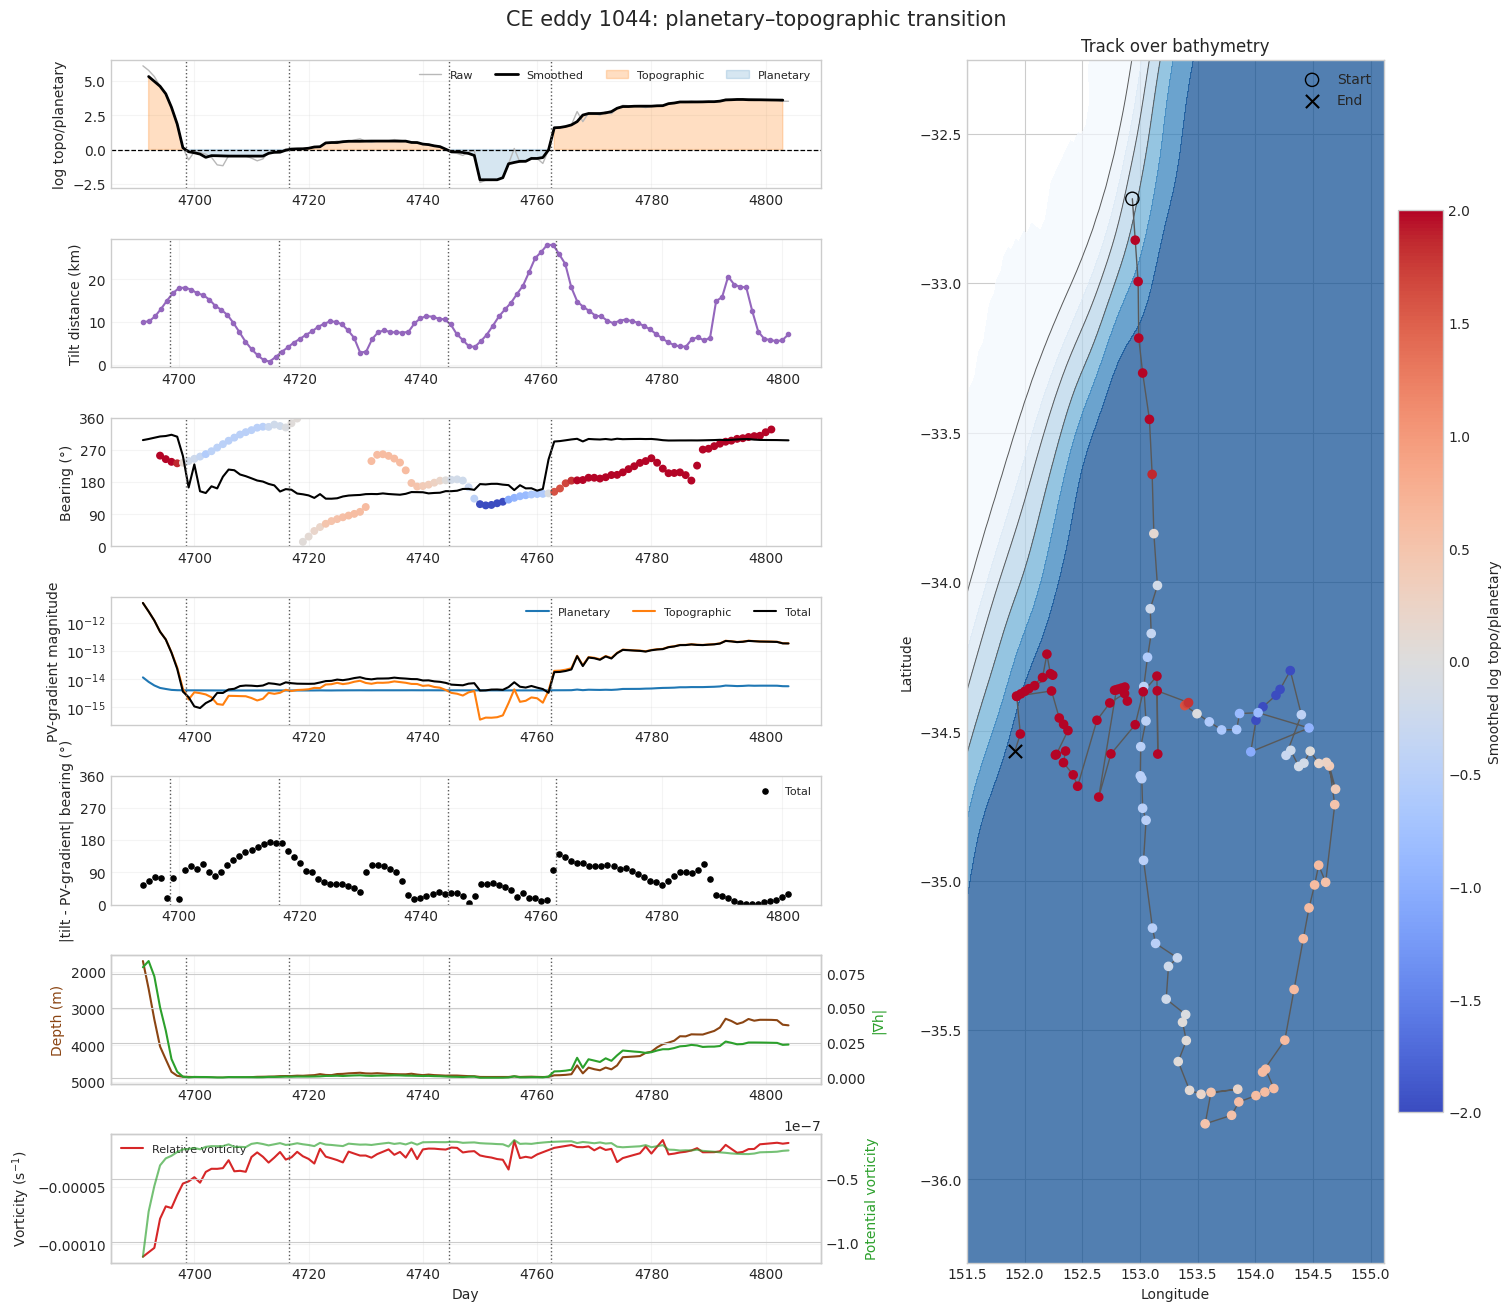

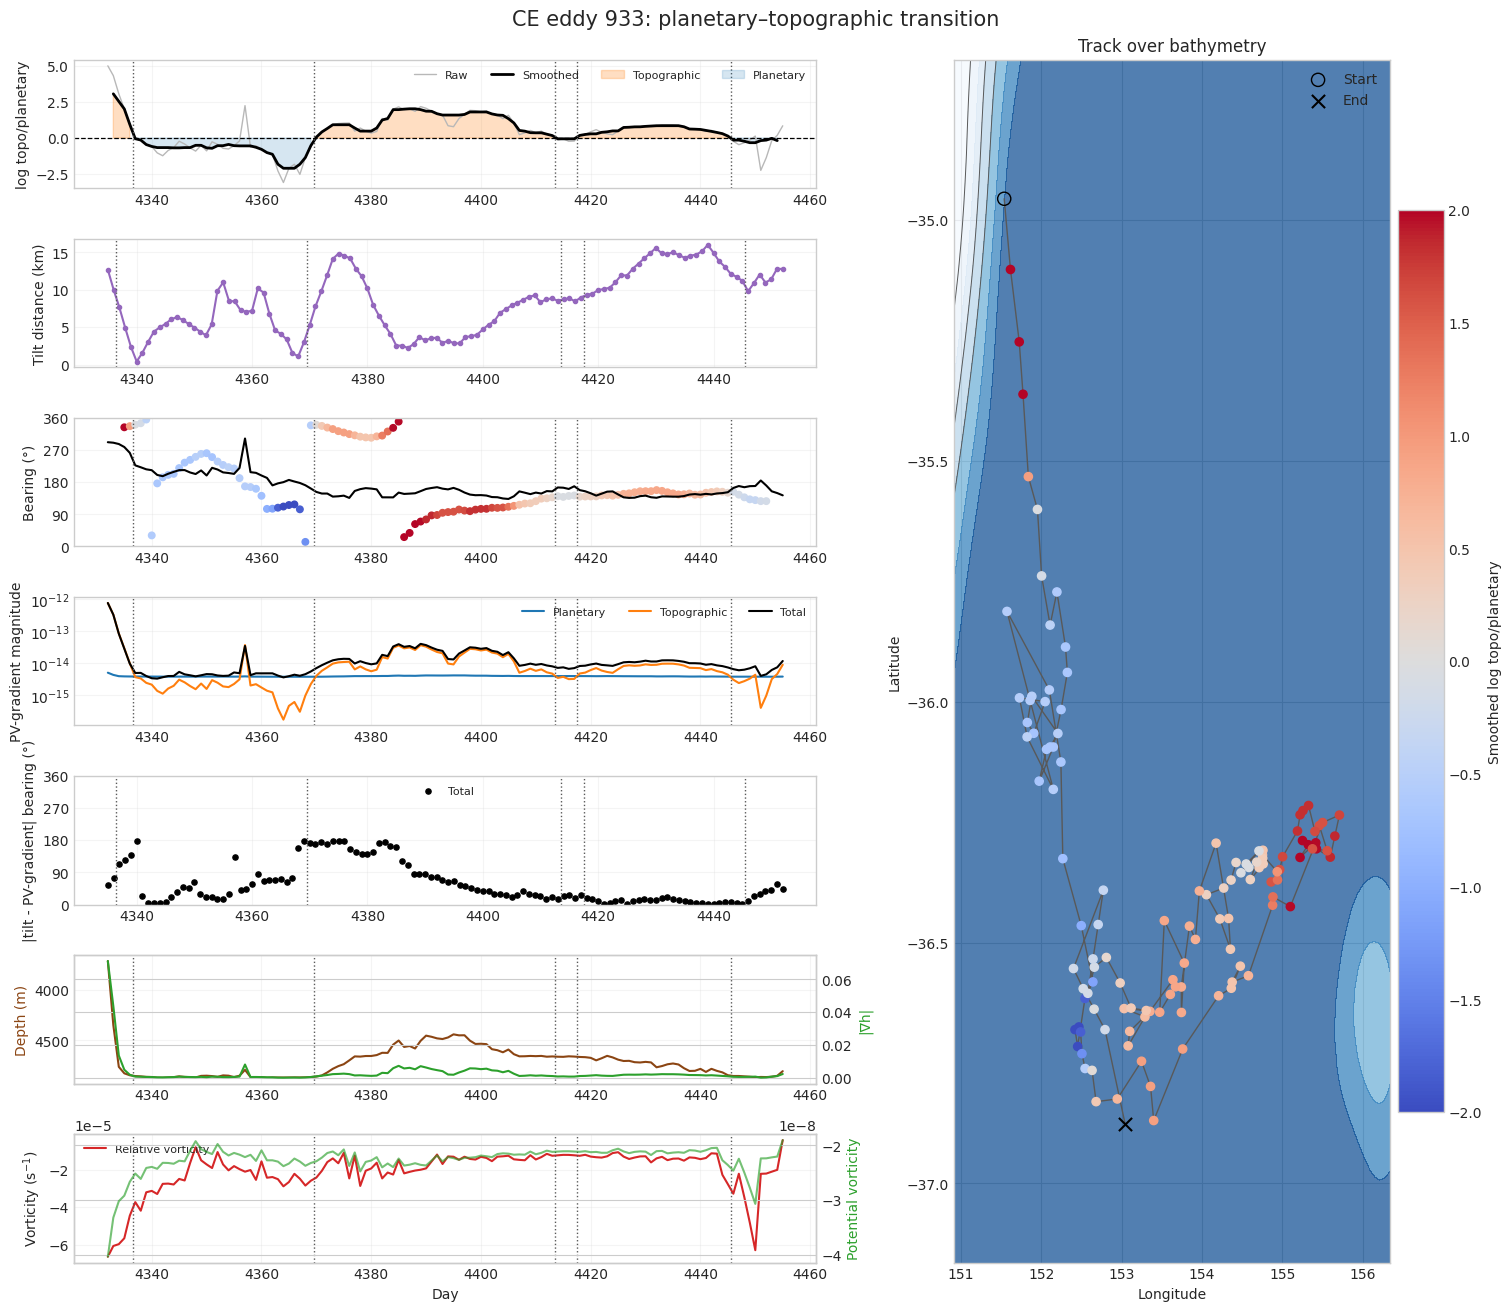

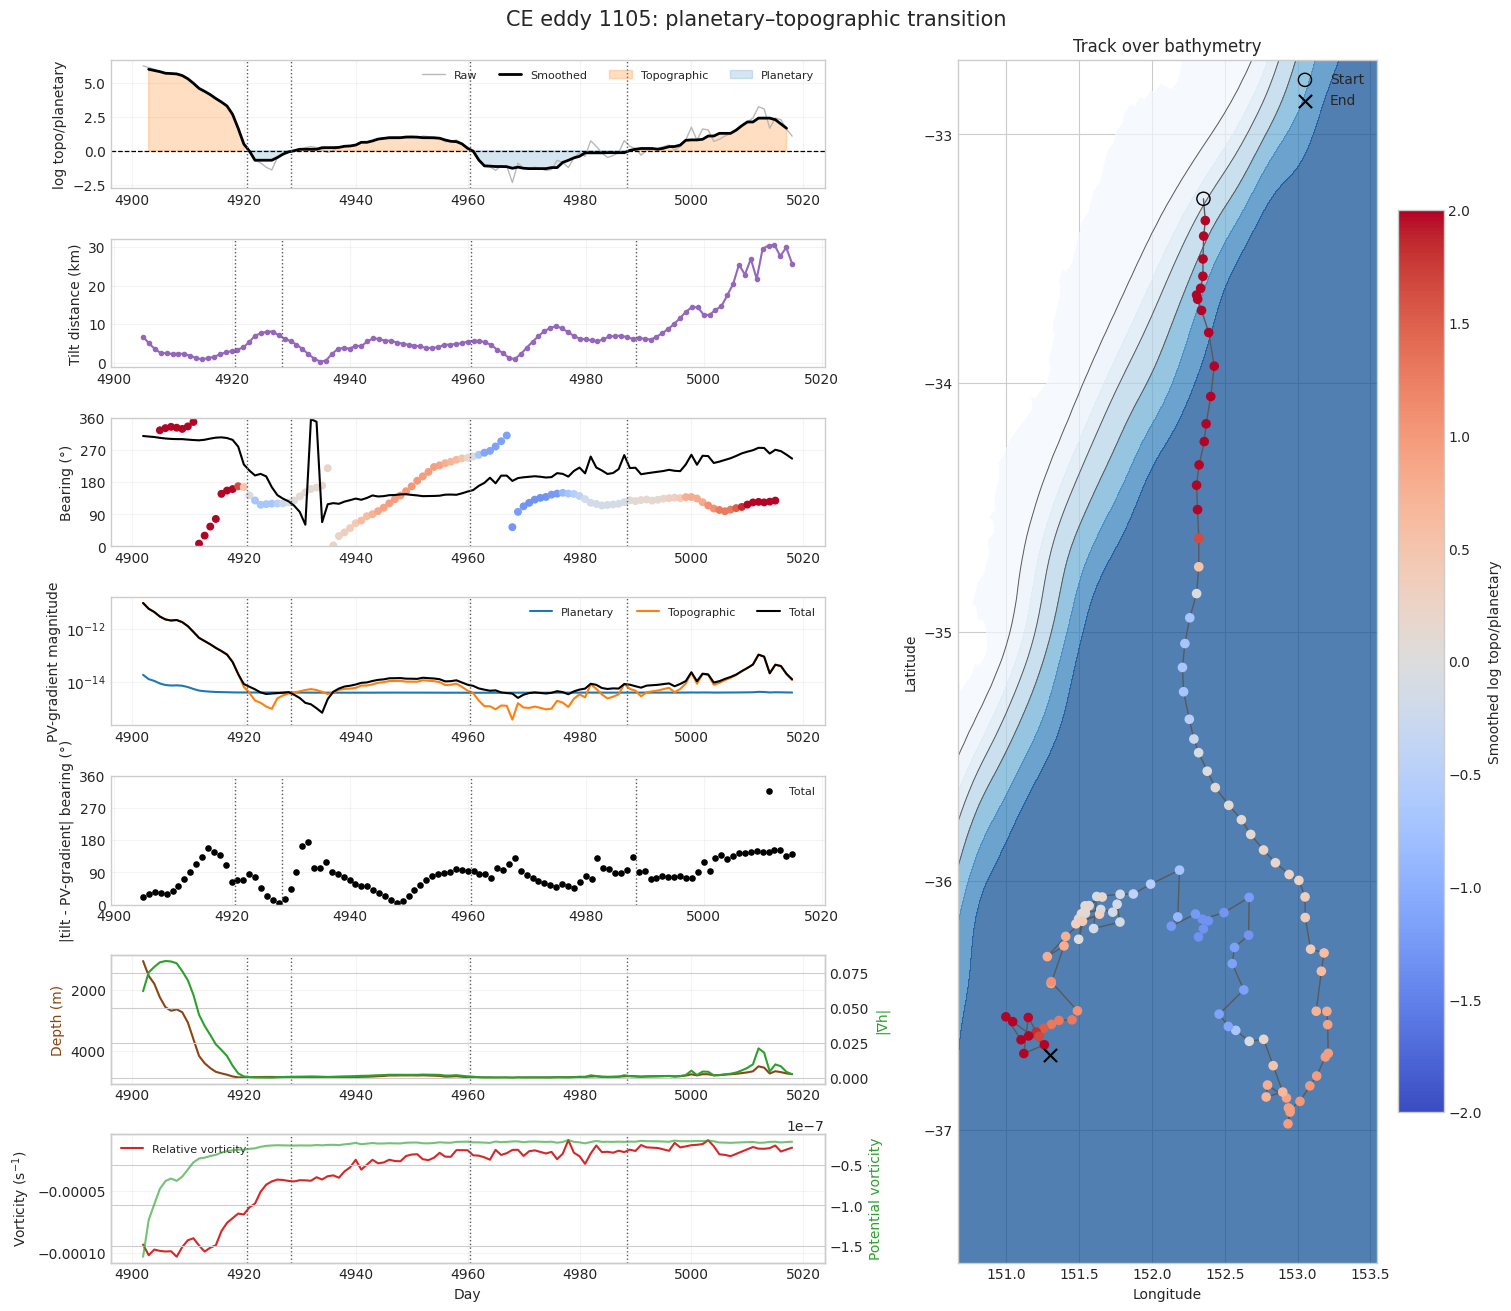

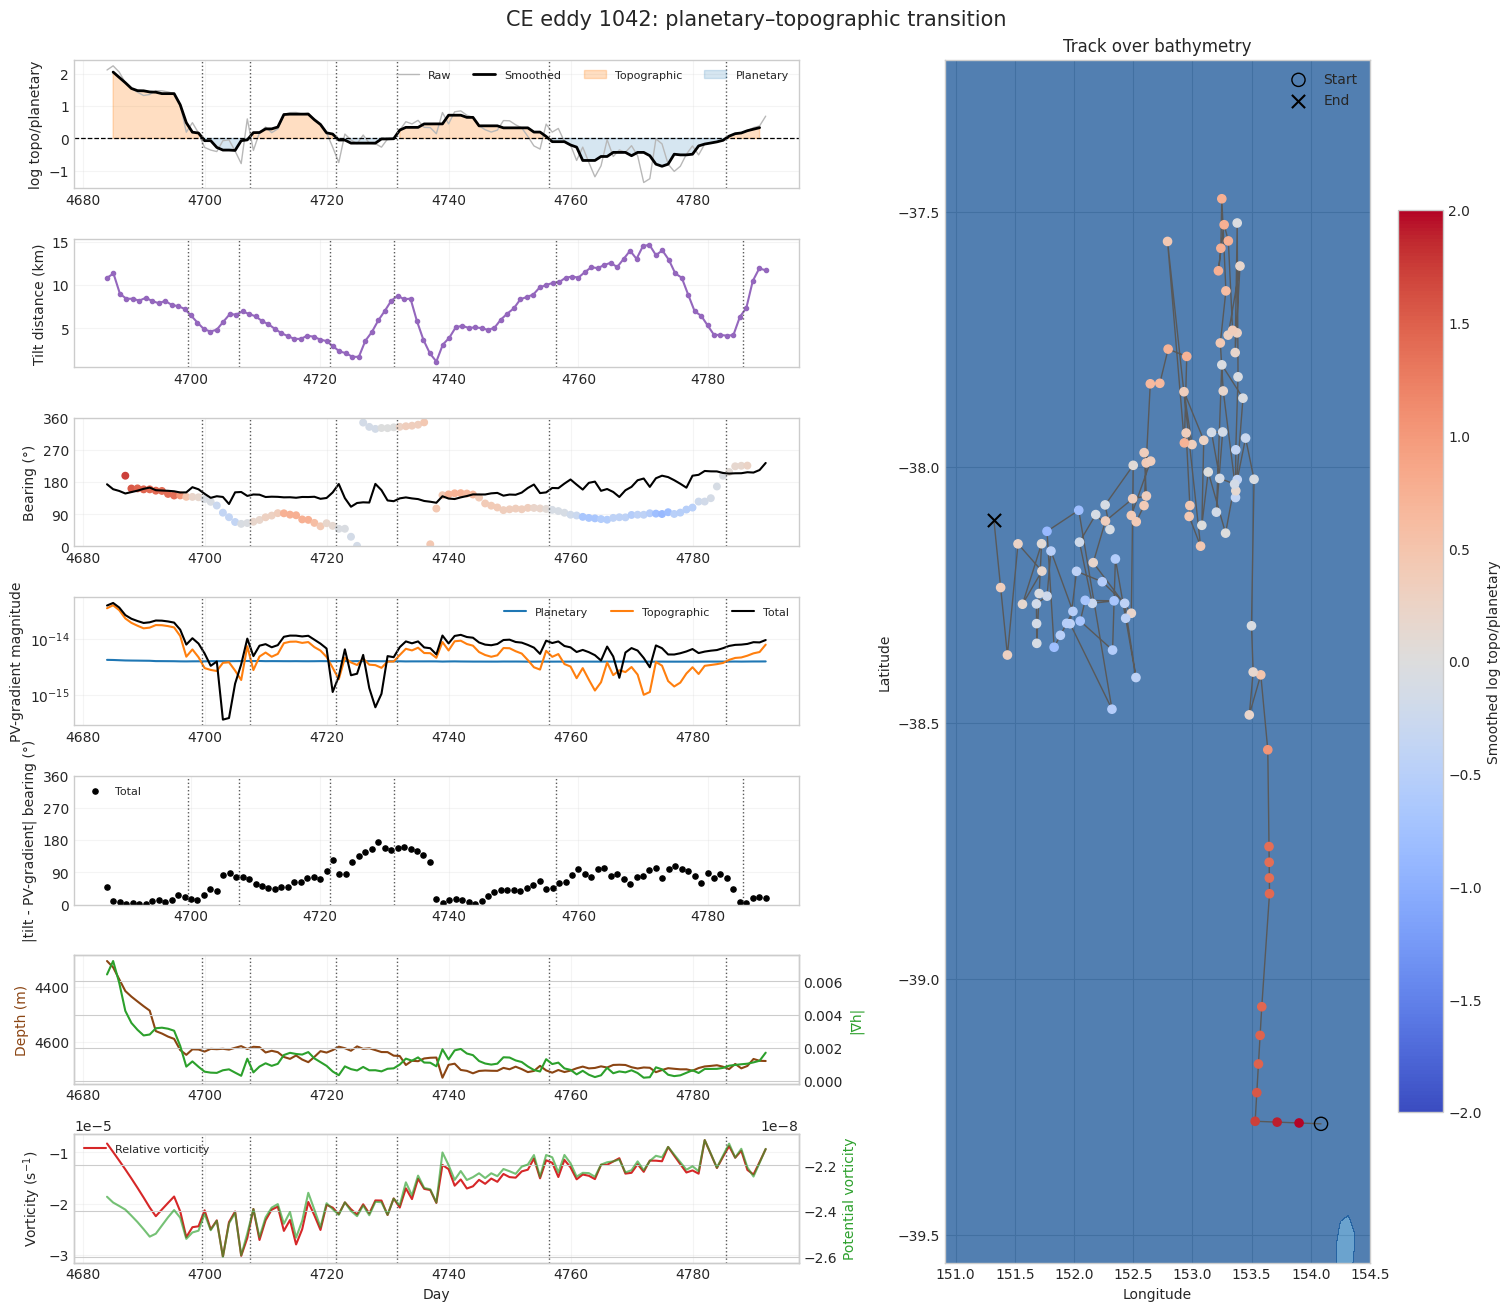

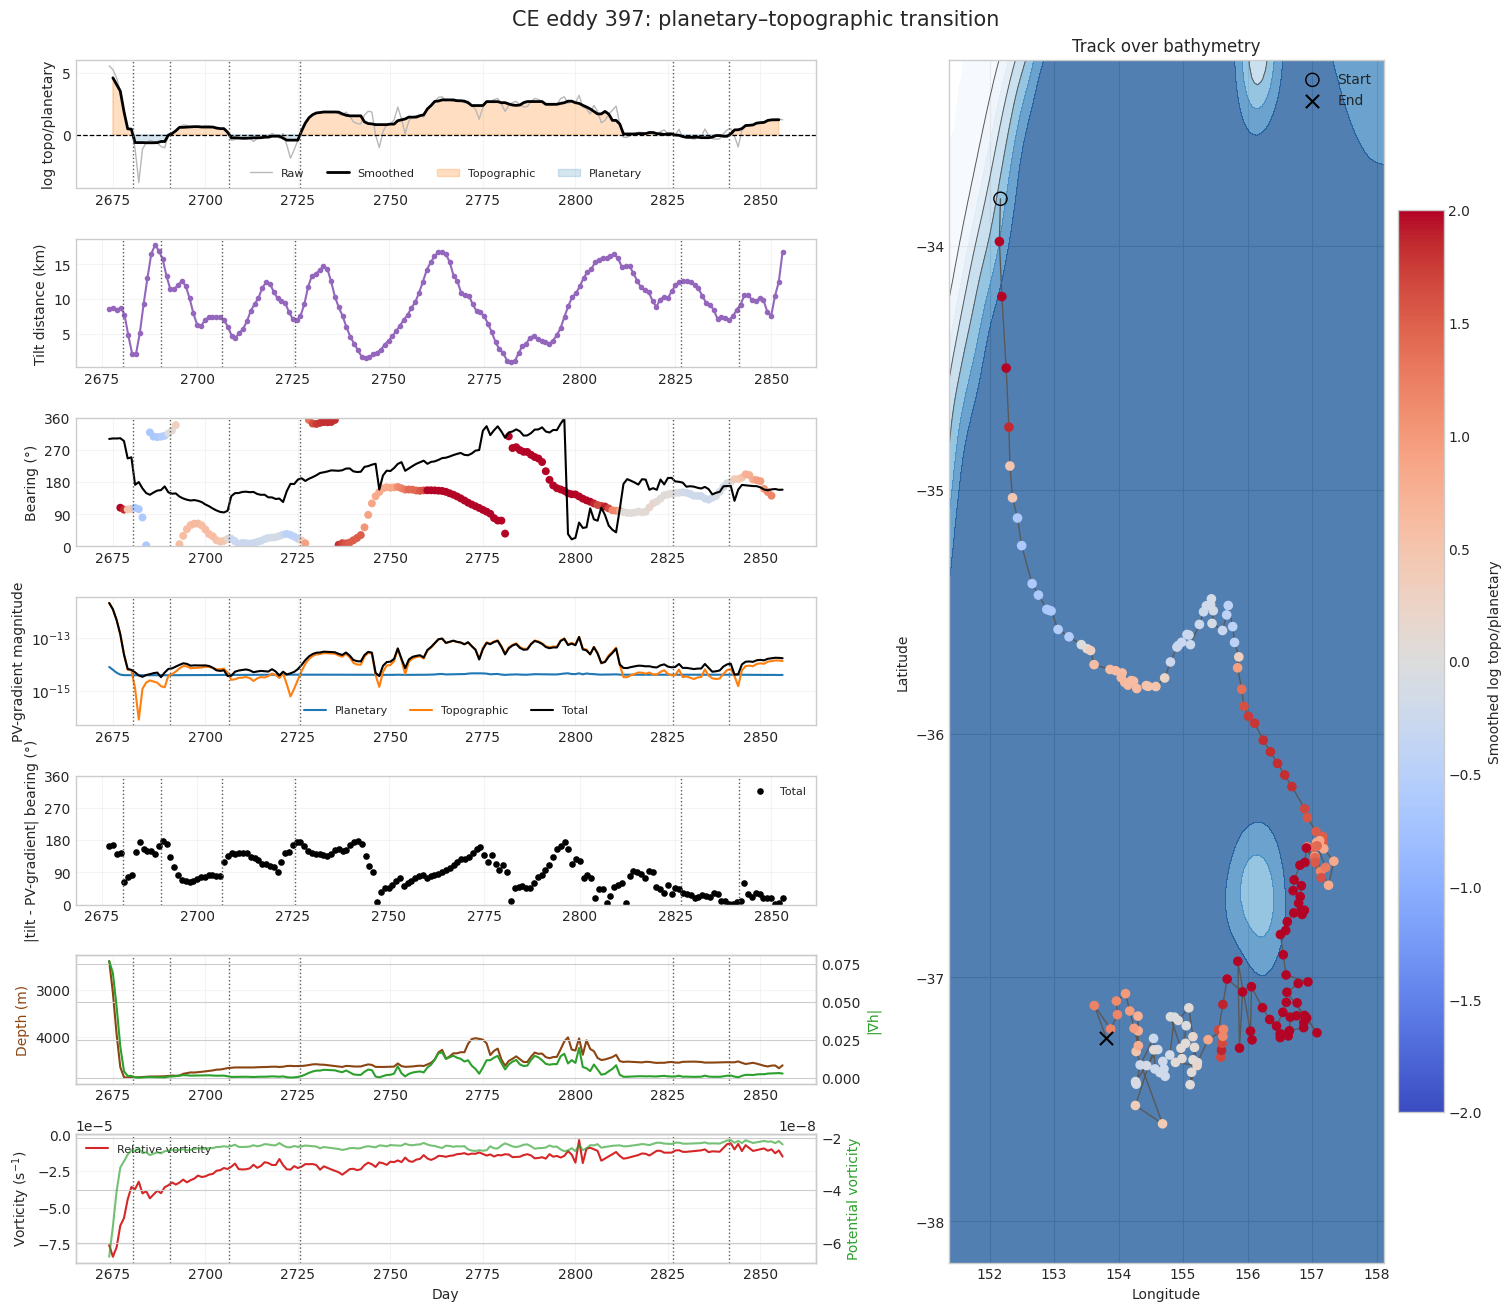

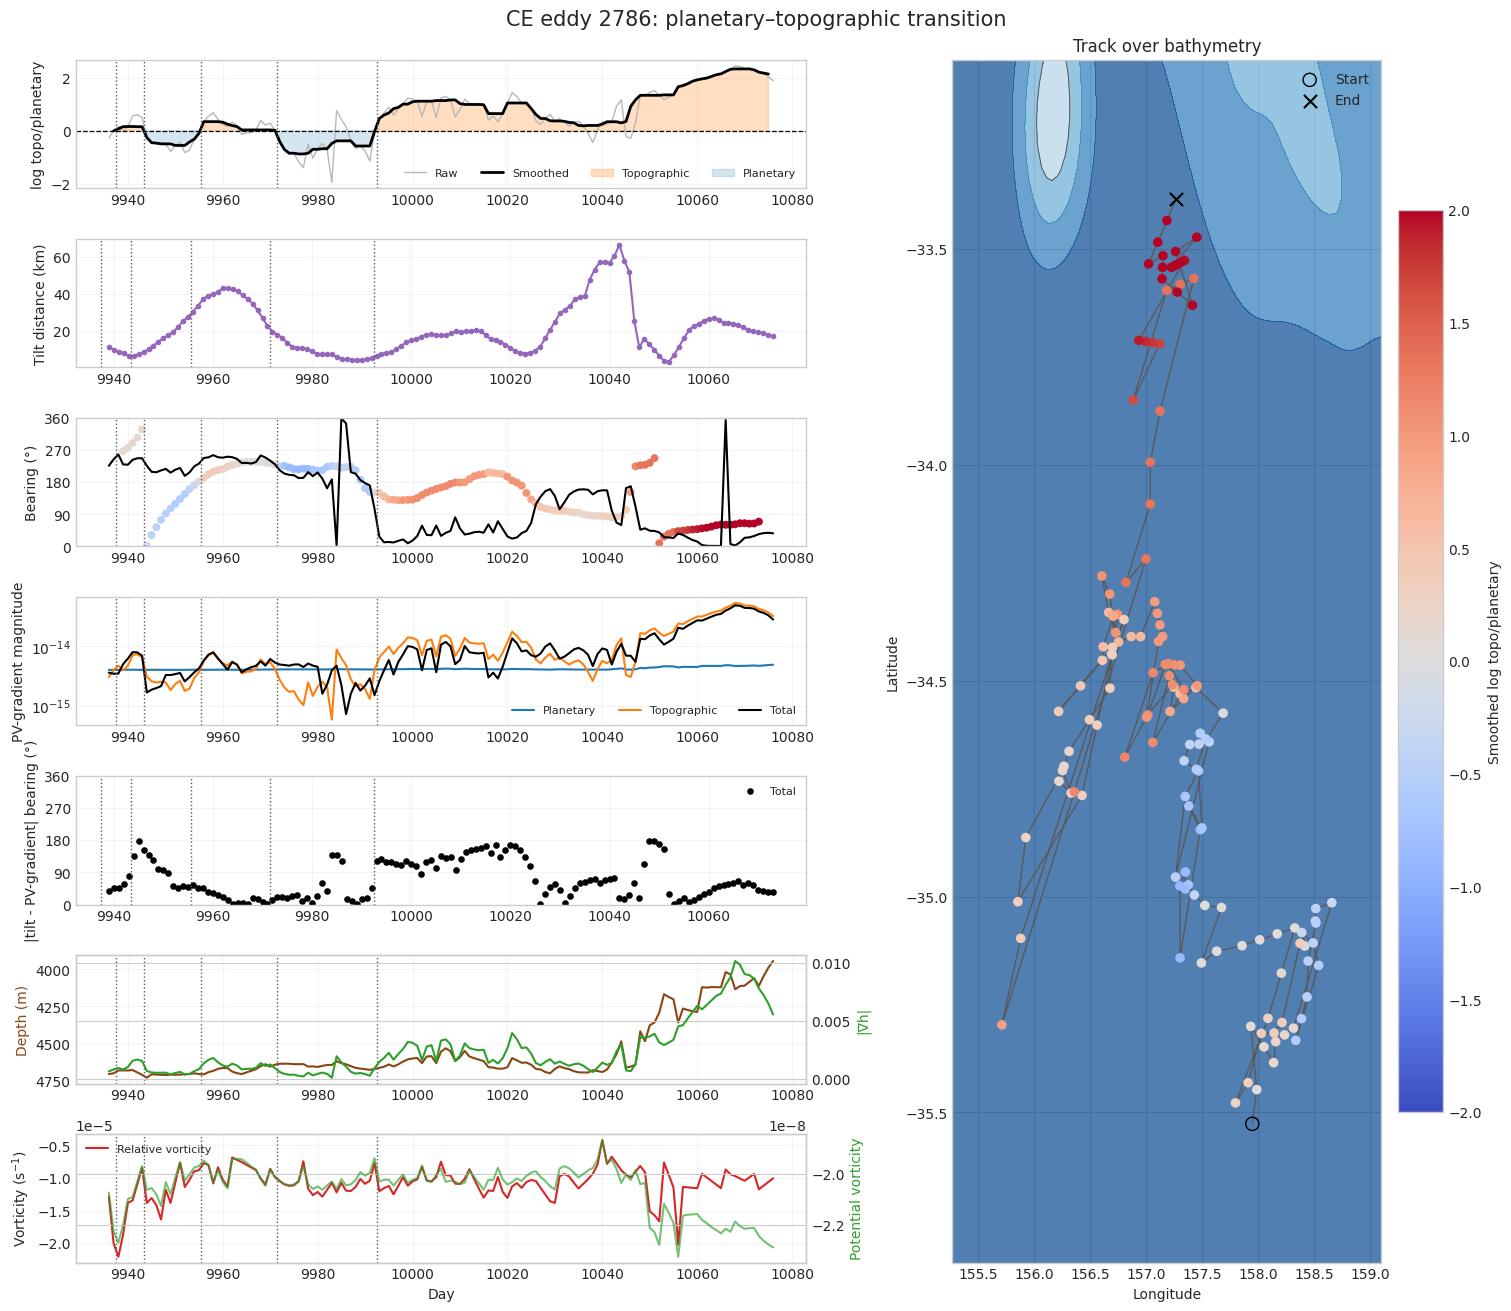

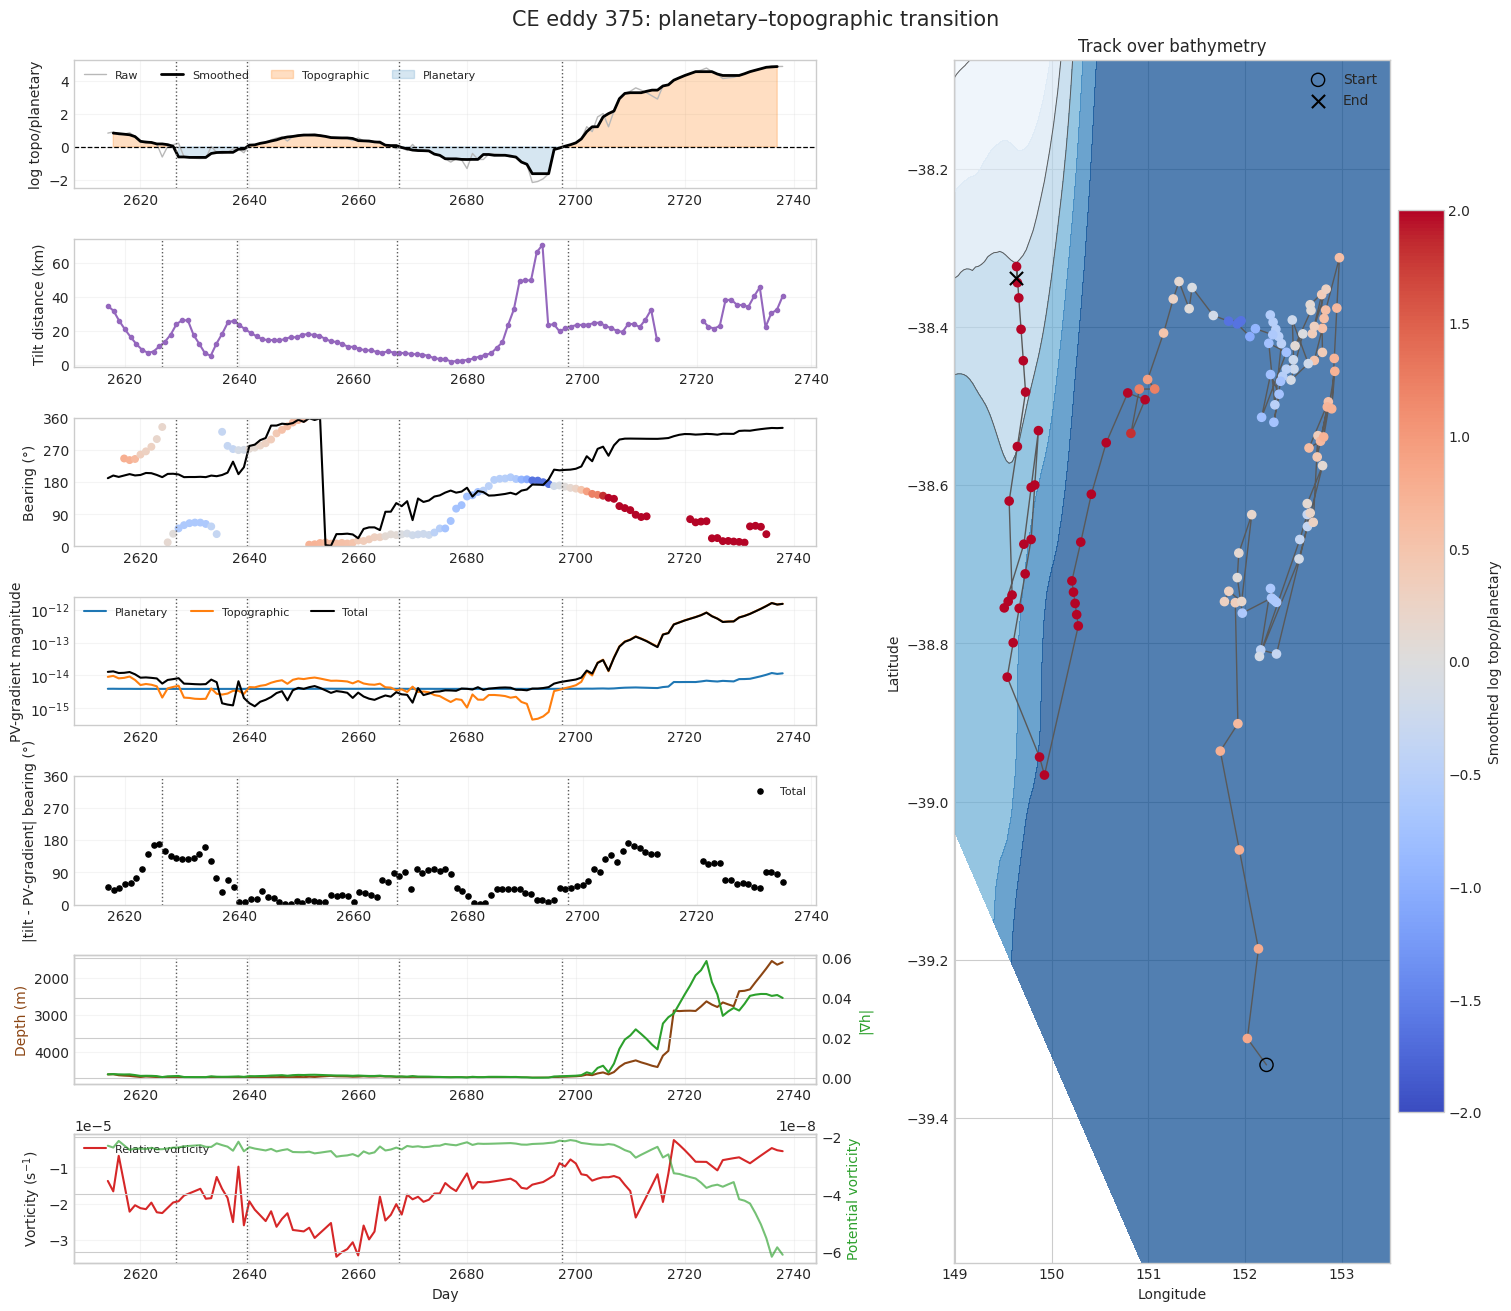

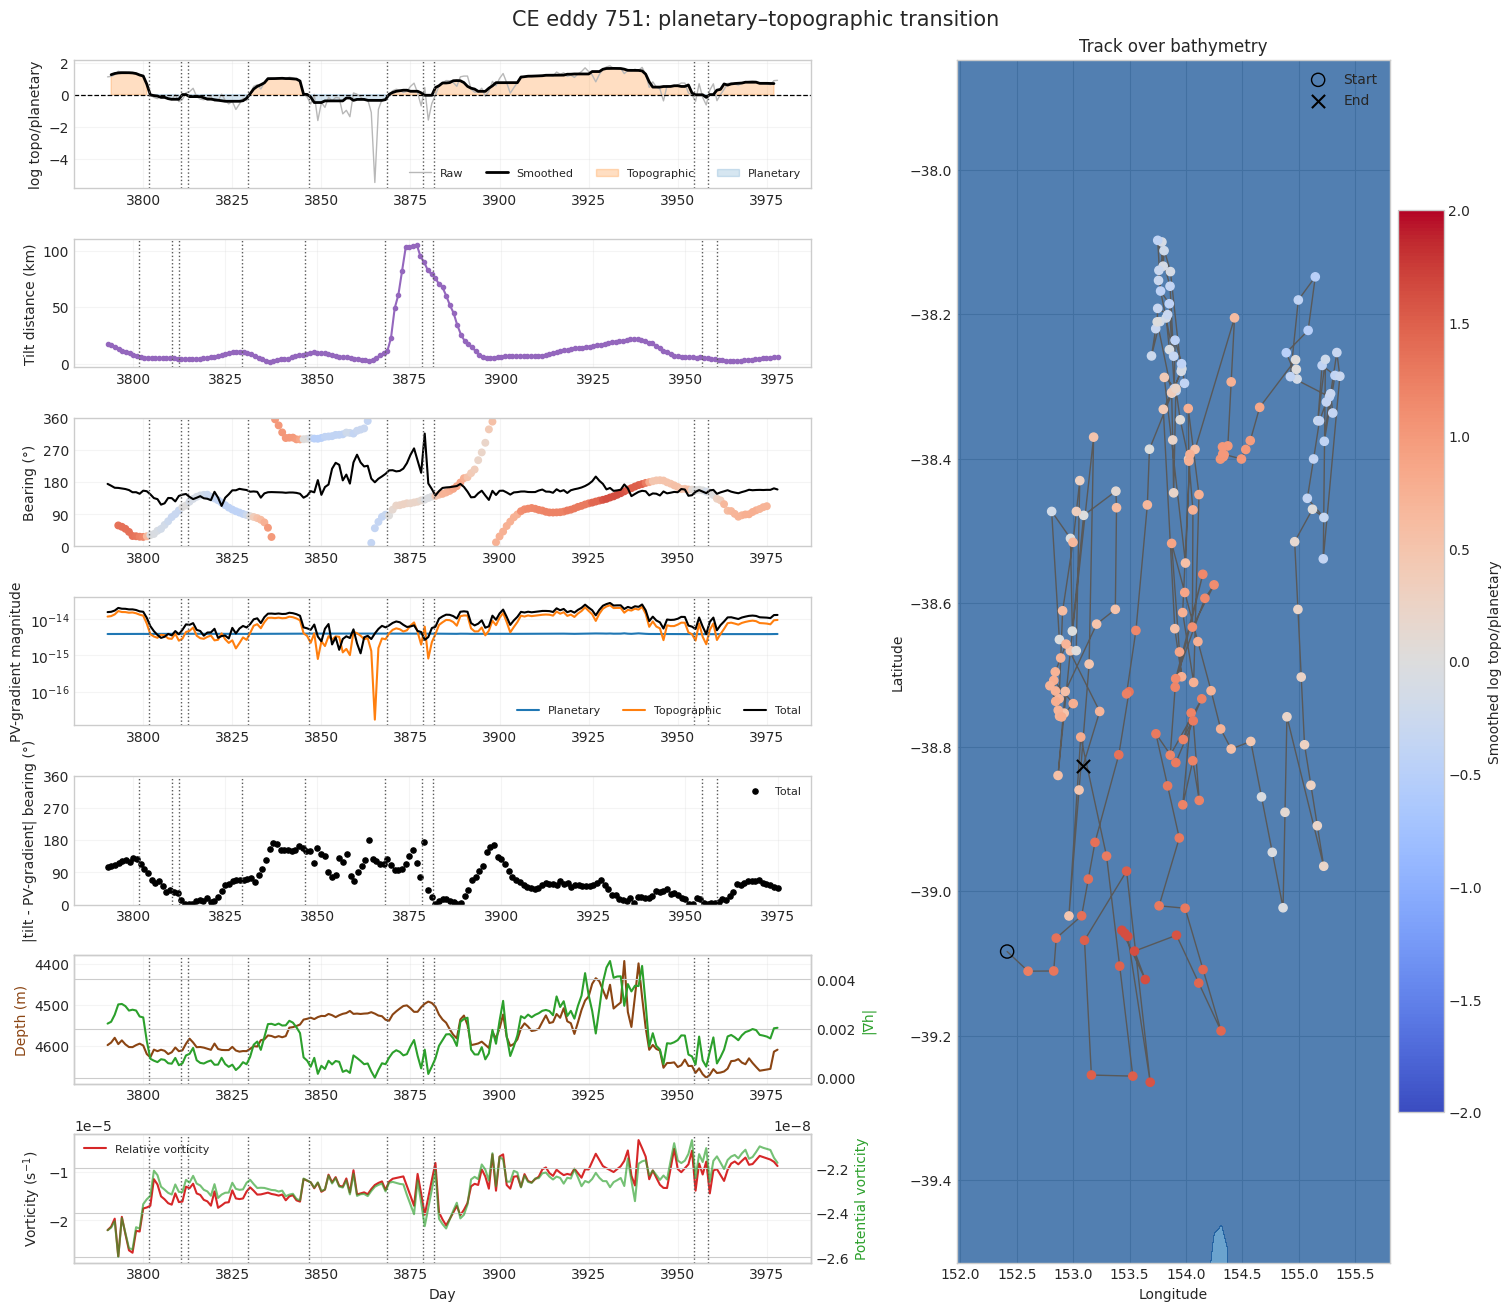

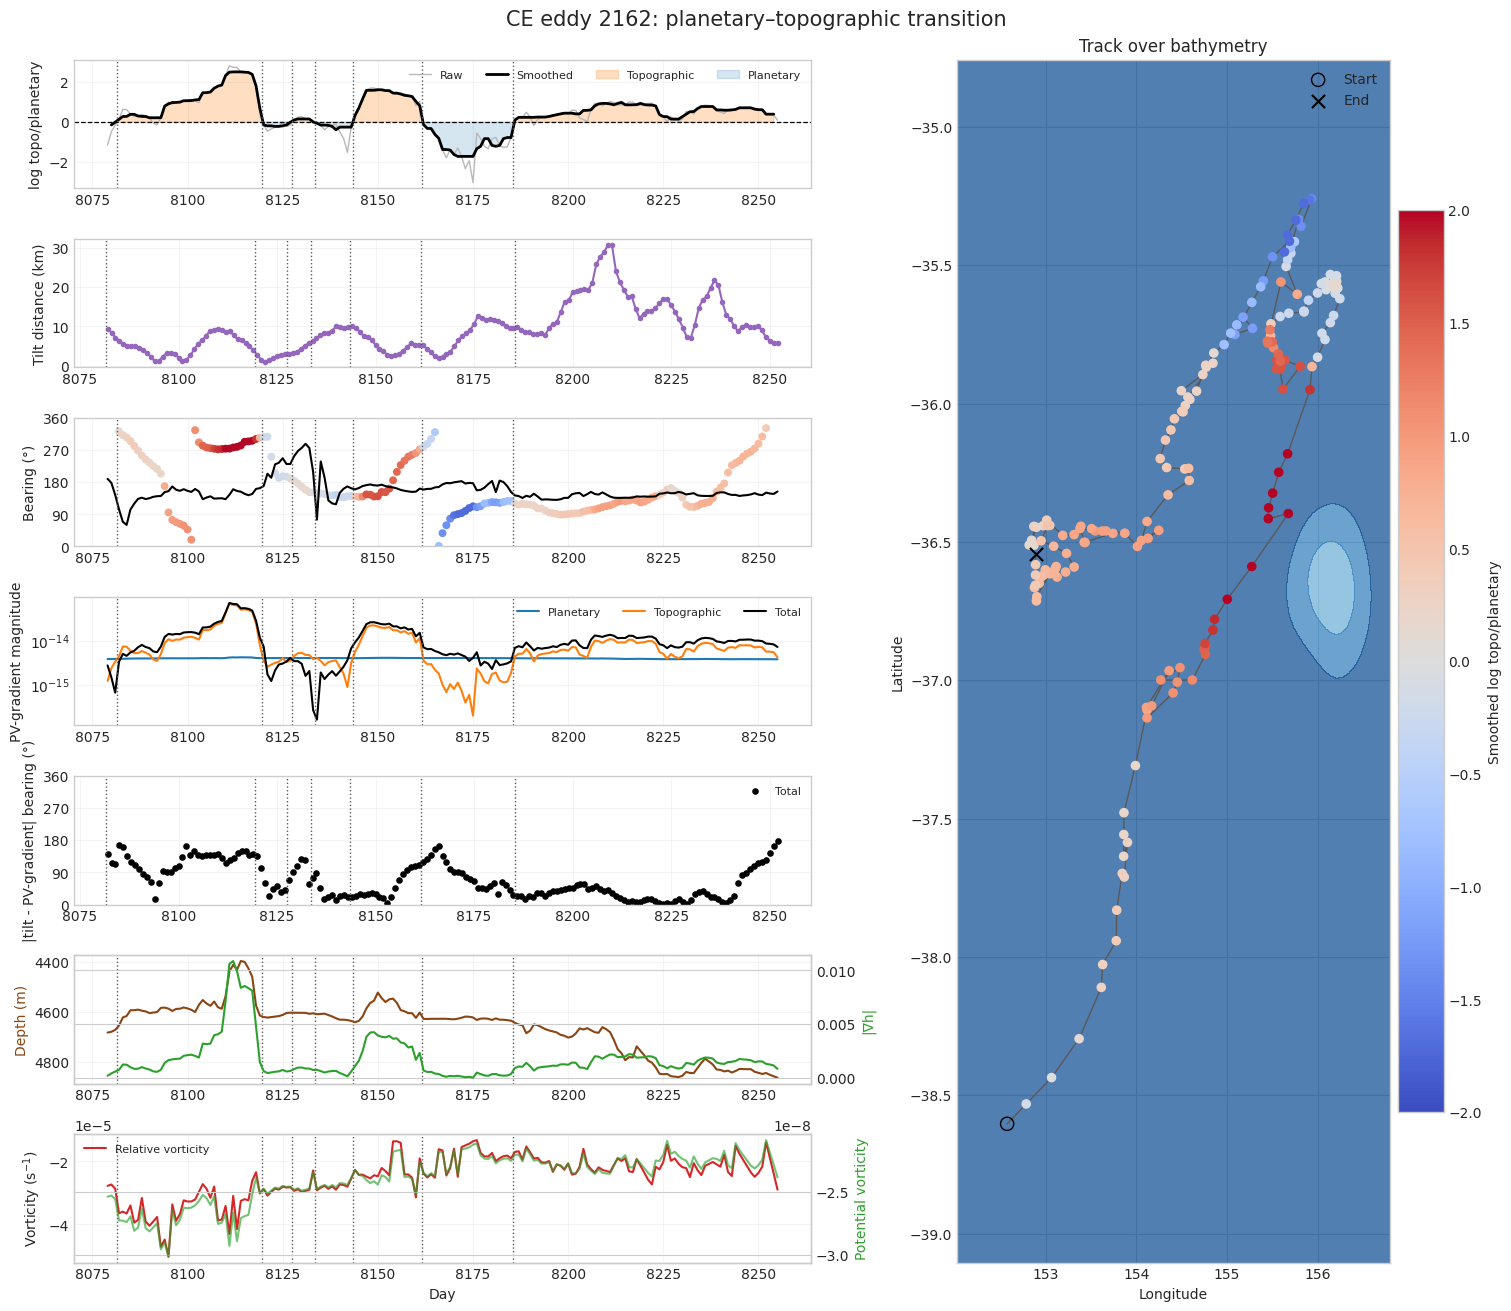

In [7]:
for cyc in ['AE', 'CE']:
    for eddy_id in selected[cyc]:
        track = df_transition[df_transition.Eddy == eddy_id].copy()
        fig, _, _ = plot_topographic_transition(
            track, grid, title=f'{cyc} eddy {eddy_id}: planetary–topographic transition'
)
        plt.show()

## 6. Within-eddy regime comparison

This descriptive table compares the same eddy between its planetary- and topographic-dominant periods. It is intended to guide case interpretation. Differences can coincide with changing age, location, strength, stratification, or background flow and should not be presented as an isolated causal estimate.

In [8]:
selected_ids = selected['AE'] + selected['CE']
comparison = df_transition[df_transition.Eddy.isin(selected_ids)].copy()
comparison['regime'] = np.select(
    [comparison.planetary_dominant, comparison.topographic_dominant],
    ['planetary', 'topographic'], default='transition'
)
comparison['slope'] = np.hypot(comparison.dhdx, comparison.dhdy)
regime_summary = (
    comparison[comparison.regime != 'transition']
    .groupby(['Cyc', 'Eddy', 'regime'])
    .agg(observations=('Day', 'size'), tilt_median_km=('TiltDis', 'median'),
         tilt_iqr_km=('TiltDis', lambda x: x.quantile(.75) - x.quantile(.25)),
         depth_median_m=('h', 'median'), slope_median=('slope', 'median'),
         ratio_median=('topo_plan_ratio_smooth', 'median'), rossby_median=('Ro', 'median'))
    .round(3)
)
display(regime_summary)

observations  tilt_median_km  tilt_iqr_km  \
Cyc Eddy regime                                                   
AE  6    planetary             118           5.739        3.659   
         topographic           107           5.107        5.169   
    42   planetary              69           5.554        5.196   
         topographic            48          11.978        5.701   
    184  planetary             206           8.754        8.706   
         topographic           229           5.670        6.803   
    356  planetary              94          21.302       15.001   
         topographic           148          18.109       20.334   
    413  planetary              43          12.362       10.261   
         topographic            60           8.018        7.154   
    604  planetary              99          19.759       15.996   
         topographic            38          11.851        7.892   
    809  planetary              66          14.902        4.996   
         topographic            41          13.131        6.203   
    1675 planetary              76          11.557       16.483   
         topographic            74          13.262       15.467   
    2255 planetary             104           7.878        7.242   
         topographic           109          11.741        6.052   
    2361 planetary              56          18.401       22.659   
         topographic            56          22.305       15.480   
CE  20   planetary              53           9.262        7.536   
         topographic           124           9.298       11.280   
    375  planetary              43          12.688       18.329   
         topographic            80          20.239       10.232   
    397  planetary              44           8.856        4.566   
         topographic           137           9.742        6.464   
    751  planetary              55           5.215        3.775   
         topographic           132           8.406       12.179   
    933  planetary              46           6.595        4.710   
         topographic            76           9.641        8.092   
    1042 planetary              47           6.977        7.282   
         topographic            60           6.844        3.518   
    1044 planetary              36          12.254       11.321   
         topographic            76           9.250        5.019   
    1105 planetary              36           6.143        1.945   
         topographic            79           5.013        8.443   
    2162 planetary              44           7.651        6.925   
         topographic           131           8.653        8.809   
    2786 planetary              34           9.832        9.911   
         topographic           105          19.622       18.749   

                      depth_median_m  slope_median  ratio_median  \
Cyc Eddy regime                                                    
AE  6    planetary          4844.193         0.001        -1.389   
         topographic        4740.093         0.011         0.867   
    42   planetary          4690.450         0.001        -0.312   
         topographic        4506.610         0.008         1.902   
    184  planetary          4827.483         0.001        -0.575   
         topographic        4743.672         0.007         0.902   
    356  planetary          4862.916         0.001        -1.040   
         topographic        4661.378         0.012         1.908   
    413  planetary          4864.818         0.000        -1.754   
         topographic        4734.549         0.010         1.680   
    604  planetary          4851.547         0.001        -1.362   
         topographic        4254.992         0.037         2.563   
    809  planetary          4623.833         0.001        -0.471   
         topographic        4087.669         0.008         1.821   
    1675 planetary          4828.377         0.001        -0.342   
         topographic        4739.409         0.006 

## Interpretation checklist

A convincing topographic case should show: (1) a sustained rather than single-day change in dominance; (2) a spatially coherent encounter with shelf/slope bathymetry; (3) a corresponding change in tilt magnitude and/or bearing; (4) a total PV-gradient response consistent with the changing topographic contribution; and (5) no obvious loss of tilt-data coverage at the transition.

The CE–AE comparison is initially balanced. If the ranked and visually checked CEs consistently show clearer responses, the final presentation can then emphasize CEs while retaining one or more AE counterexamples.